In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.labels import LabelLoader
from src.loader import SimulationLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from config import SIM7200_DIR, LABEL_FILE, DATA_DIR, MIN_SEQUENCE_LEN

loader = SimulationLoader(SIM7200_DIR)
labels = LabelLoader(LABEL_FILE)


In [3]:
from pathlib import Path

filepath = SIM7200_DIR / "00002_balance_readable.xlsx"

print(filepath)
print("Exists:", filepath.exists())
print("Size:", filepath.stat().st_size, "bytes")

/home/ikeaprash/project/data/7200 sec Run/00002_balance_readable.xlsx
Exists: True
Size: 3476061 bytes


In [5]:
simid=43
sim = loader.load_simulation(simid)
print(labels.get_initial_conclusion(simid))
balance = sim["balance"]
temp = sim["temperature"]

balance

/home/ikeaprash/project/data/7200 sec Run/00043_balance_readable.xlsx
Timed Out


,time,dt,mg,mgd,ml,mld,mp,mpd,mm,mmd,...,errmg,errmli,errml,erregi,erreg,erreli,errel,errepi,errep,m(Corium)
0,0.00100,0.00100,11.12229,0.02831,215521.47,8793.10990,249897.77,0,0,0,...,-0.02831,-0.01992,-19.92208,1.097500e-01,109.74827,-12778.208,-1.277821e+07,-2.477000e-02,-24.77304,249897.77
1,1.00887,0.00818,69.27136,34.17926,179863.55,-38665.95700,249897.77,0,0,0,...,0.00289,-5.05519,-0.49856,-5.385263e+02,212.67986,-79742.626,-3.173260e+03,8.161422e+02,26.25384,249897.77
2,2.00993,0.02593,82.42360,4.85536,155959.60,-10925.31100,249897.77,0,0,0,...,0.00986,-18.13653,-0.03589,3.140427e+02,-539.12349,-73241.471,-3.794455e+02,7.817913e+02,958.33587,249897.77
3,3.02239,0.06576,84.82070,-1.10321,151694.18,1141.45980,249897.77,0,0,0,...,0.00067,-30.38216,1.08928,-1.416210e+03,-4876.76760,-64901.812,4.771204e+03,1.466164e+03,2838.40460,249897.77
4,4.16573,0.16362,82.98825,-1.72054,154012.54,2355.90270,249897.77,0,0,0,...,-0.01063,-23.61128,0.17427,-6.380285e+03,2073.60450,-61191.972,2.208341e+02,2.857361e+03,-1622.55260,249897.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6018,7195.21160,0.39052,66.68986,-0.00543,195523.28,0.64647,249897.77,0,0,0,...,0.00498,-1529.54110,-0.00824,-1.574682e+07,-1036.83100,-9509555.300,1.291222e+04,7.870333e+06,-491.88110,249897.77
6019,7196.29350,0.20245,66.68965,0.00100,195523.66,0.48663,249897.77,0,0,0,...,-0.00091,-1529.65030,-0.04628,-1.574710e+07,-569.68030,-9507087.000,1.142392e+04,7.870338e+06,-20.44393,249897.77
6020,7197.46460,0.25188,66.69426,0.00766,195522.91,-2.57127,249897.77,0,0,0,...,-0.00131,-1529.80420,-0.32052,-1.574844e+07,153.76343,-9510127.900,-2.817438e+04,7.870793e+06,-109.26675,249897.77
6021,7198.62060,0.18802,66.69868,0.01197,195521.46,-1.00154,249897.77,0,0,0,...,-0.00852,-1530.08610,-0.12847,-1.574849e+07,-2641.48740,-9512810.800,-5.390072e+03,7.870467e+06,1304.87960,249897.77


In [7]:
targets = [
    "mg", "ml", "mp",
    "eg", "el", "ep",
    "fgin", "fgout",
    "flin", "flout",
    "qgin", "qgout",
    "qlin", "qlout",
    "qpin", "qpout",
    "qsi", "qgi", "qli",
    "qsg", "qsl",
    "pow",
]

print("Number of targets:", len(targets))

target_stats = balance[targets].describe().T

target_stats

Number of targets: 22


,count,mean,std,min,25%,50%,75%,max
mg,6023.0,6.903705e+01,3.465722e+00,1.112229e+01,6.661324e+01,6.740814e+01,7.095173e+01,9.905639e+01
ml,6023.0,1.920380e+05,4.053891e+03,1.516942e+05,1.910157e+05,1.929373e+05,1.946020e+05,2.155215e+05
mp,6023.0,2.498978e+05,5.821249e-11,2.498978e+05,2.498978e+05,2.498978e+05,2.498978e+05,2.498978e+05
eg,6023.0,1.944665e+08,1.344953e+07,3.981310e+07,1.846915e+08,1.898806e+08,2.003278e+08,3.051625e+08
el,6023.0,1.128831e+11,2.427850e+09,8.902890e+10,1.122786e+11,1.134359e+11,1.144248e+11,1.264885e+11
ep,6023.0,6.326283e+10,1.104012e+10,5.020799e+10,5.305803e+10,6.070459e+10,7.192660e+10,9.174786e+10
fgin,6023.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
fgout,6023.0,1.034732e+01,2.281446e+00,0.000000e+00,8.980955e+00,1.016797e+01,1.119189e+01,3.545116e+01
flin,6023.0,5.632751e+01,1.440864e+02,8.020210e+00,3.859987e+01,4.280730e+01,5.164612e+01,8.773188e+03
flout,6023.0,4.514066e+01,5.196579e+02,0.000000e+00,2.719623e+01,3.298436e+01,3.405007e+01,3.864029e+04


In [8]:
zero_fraction = (
    (balance[targets] == 0)
    .mean()
    .sort_values(ascending=False)
)

zero_fraction

qgi      1.000000
qsl      1.000000
qpin     1.000000
qpout    1.000000
qgin     1.000000
fgin     1.000000
qlout    0.055288
flout    0.055288
qsi      0.000166
qli      0.000166
fgout    0.000166
qgout    0.000166
ml       0.000000
mg       0.000000
ep       0.000000
el       0.000000
eg       0.000000
mp       0.000000
qlin     0.000000
flin     0.000000
qsg      0.000000
pow      0.000000
dtype: float64

In [9]:
negative_fraction = (
    (balance[targets] < 0)
    .mean()
    .sort_values(ascending=False)
)

negative_fraction

qsg      1.000000
qli      0.999502
mp       0.000000
eg       0.000000
mg       0.000000
ml       0.000000
ep       0.000000
el       0.000000
fgin     0.000000
fgout    0.000000
qgin     0.000000
qgout    0.000000
flin     0.000000
flout    0.000000
qlout    0.000000
qlin     0.000000
qpin     0.000000
qpout    0.000000
qgi      0.000000
qsi      0.000000
qsl      0.000000
pow      0.000000
dtype: float64

In [11]:

sim = (
    balance
    .sort_values("time")
)

print(sim.shape)
print(sim[["time"] + targets].head())

(6023, 101)
      time        mg         ml         mp         eg            el  \
0  0.00100  11.12229  215521.47  249897.77   39813100  126488480000   
1  1.00887  69.27136  179863.55  249897.77  242310890  105563210000   
2  2.00993  82.42360  155959.60  249897.77  287544160   91532544000   
3  3.02239  84.82070  151694.18  249897.77  295212290   89028901000   
4  4.16573  82.98825  154012.54  249897.77  287644940   90389526000   

            ep  fgin     fgout        flin  ...          qlin         qlout  \
0  91747861000     0   0.00000  8773.18790  ...  5.148940e+09  0.000000e+00   
1  91594512000     0   0.00023     8.02021  ...  4.707532e+06  2.267780e+10   
2  91530712000     0  23.06204     8.02021  ...  4.707149e+06  6.400351e+09   
3  91466289000     0  29.49469  1170.94130  ...  6.872196e+08  0.000000e+00   
4  91392505000     0  30.61469  2384.96050  ...  1.399721e+09  0.000000e+00   

   qpin  qpout       qsi  qgi        qli           qsg  qsl       pow  
0     0      0

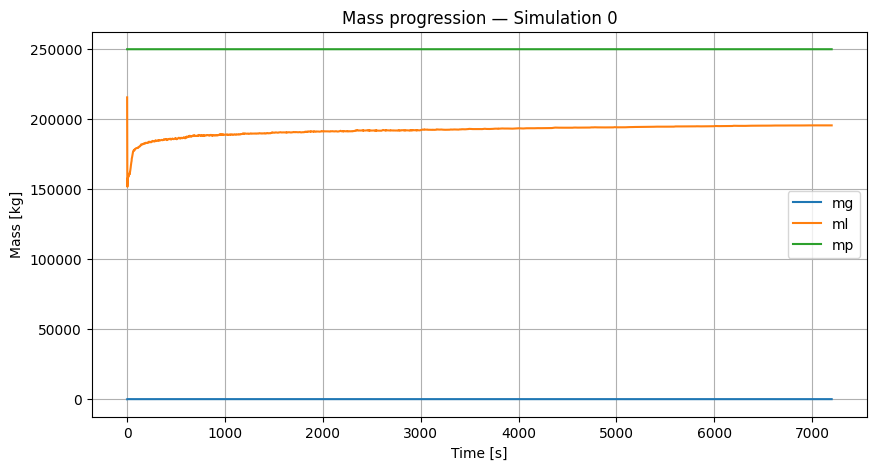

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(sim["time"], sim["mg"], label="mg")
ax.plot(sim["time"], sim["ml"], label="ml")
ax.plot(sim["time"], sim["mp"], label="mp")

ax.set_xlabel("Time [s]")
ax.set_ylabel("Mass [kg]")
ax.set_title(f"Mass progression — Simulation {sim_id}")
ax.legend()
ax.grid(True)

plt.show()

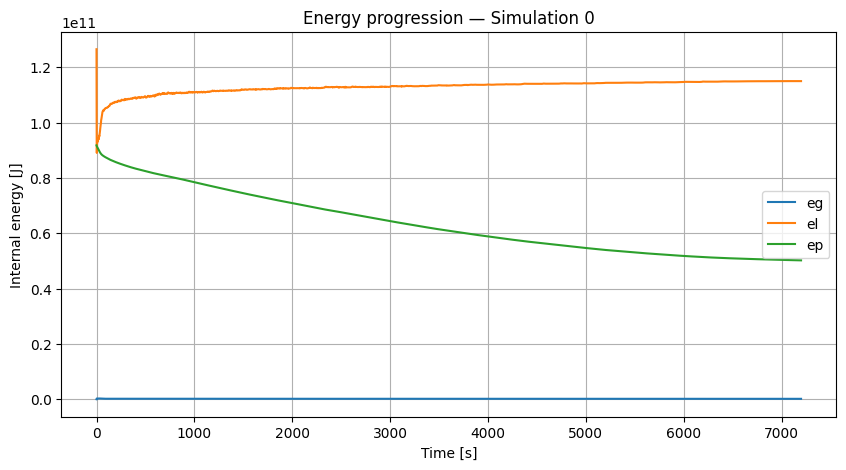

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(sim["time"], sim["eg"], label="eg")
ax.plot(sim["time"], sim["el"], label="el")
ax.plot(sim["time"], sim["ep"], label="ep")

ax.set_xlabel("Time [s]")
ax.set_ylabel("Internal energy [J]")
ax.set_title(f"Energy progression — Simulation {sim_id}")
ax.legend()
ax.grid(True)

plt.show()

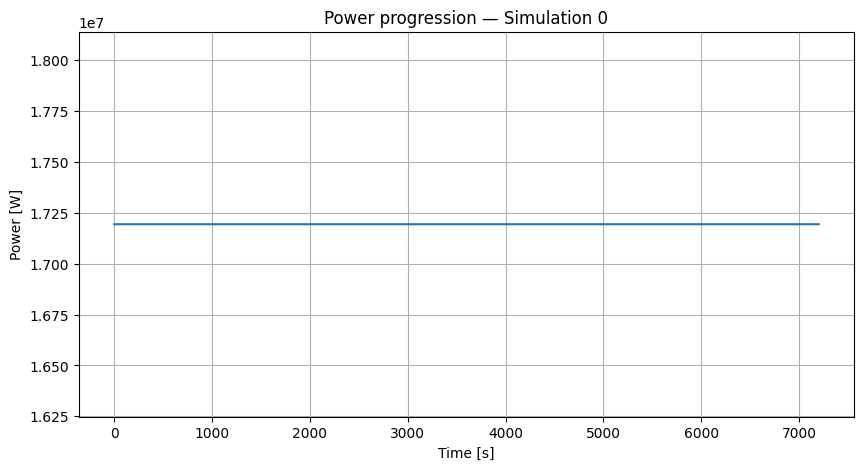

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(
    sim["time"],
    sim["pow"]
)

plt.xlabel("Time [s]")
plt.ylabel("Power [W]")
plt.title(f"Power progression — Simulation {sim_id}")
plt.grid(True)

plt.show()

In [15]:
print(sim.columns.tolist())

['time', 'dt', 'mg', 'mgd', 'ml', 'mld', 'mp', 'mpd', 'mm', 'mmd', 'mc', 'mcd', 'md', 'mdd', 'mlay', 'mlayd', 'eg', 'egd', 'el', 'eld', 'ep', 'epd', 'ec', 'ecd', 'em', 'emd', 'ed', 'edd', 'elay', 'elayd', 'fgini', 'fgin', 'fgouti', 'fgout', 'flini', 'flin', 'flouti', 'flout', 'fdini', 'fdin', 'fdouti', 'fdout', 'flayini', 'flayin', 'flayouti', 'flayout', 'qgini', 'qgin', 'qgouti', 'qgout', 'qlini', 'qlin', 'qlouti', 'qlout', 'qpini', 'qpin', 'qpouti', 'qpout', 'qdini', 'qdin', 'qdouti', 'qdout', 'qlayini', 'qlayin', 'qlayouti', 'qlayout', 'gevi', 'gev', 'qsii', 'qsi', 'qgii', 'qgi', 'qlii', 'qli', 'qsgi', 'qsg', 'qsli', 'qsl', 'qdti', 'qdt', 'qdri', 'qdr', 'qdii', 'qdi', 'qdgi', 'qdg', 'qlaytopi', 'qlaytop', 'powi', 'pow', 'errmgi', 'errmg', 'errmli', 'errml', 'erregi', 'erreg', 'erreli', 'errel', 'errepi', 'errep', 'm(Corium)']


In [16]:
print(sim.shape)
print(sim[["time", "eg"]].head())
print(sim[["time", "eg"]].tail())

(6023, 101)
      time         eg
0  0.00100   39813100
1  1.00887  242310890
2  2.00993  287544160
3  3.02239  295212290
4  4.16573  287644940
           time         eg
6018  7195.2116  183607740
6019  7196.2935  183606740
6020  7197.4646  183616930
6021  7198.6206  183627850
6022  7199.7610  183632090


In [17]:
sim = sim.copy()

sim["maximum_time"] = sim["time"].max()

sim["t_norm"] = (
    sim["time"] / sim["maximum_time"]
)

sim["log1p_t_norm"] = np.log1p(
    sim["t_norm"]
)

sim["sqrt_t_norm"] = np.sqrt(
    sim["t_norm"]
)

sim["t_norm_squared"] = (
    sim["t_norm"] ** 2
)

sim["log1p_maximum_time"] = np.log1p(
    sim["maximum_time"]
)

In [18]:
sim[
    [
        "time",
        "maximum_time",
        "t_norm",
        "log1p_t_norm",
        "sqrt_t_norm",
        "t_norm_squared",
        "log1p_maximum_time",
    ]
].head()

,time,maximum_time,t_norm,log1p_t_norm,sqrt_t_norm,t_norm_squared,log1p_maximum_time
0,0.00100,7199.761,1.388935e-07,1.388935e-07,0.000373,1.929140e-14,8.881942
1,1.00887,7199.761,1.401255e-04,1.401157e-04,0.011837,1.963515e-08,8.881942
2,2.00993,7199.761,2.791662e-04,2.791273e-04,0.016708,7.793377e-08,8.881942
3,3.02239,7199.761,4.197903e-04,4.197022e-04,0.020489,1.762239e-07,8.881942
4,4.16573,7199.761,5.785928e-04,5.784255e-04,0.024054,3.347696e-07,8.881942


In [19]:
target_columns = [
    "mg", "ml", "mp",
    "eg", "el", "ep",
    "fgin", "fgout",
    "flin", "flout",
    "qgin", "qgout",
    "qlin", "qlout",
    "qpin", "qpout",
    "qsi", "qgi", "qli",
    "qsg", "qsl",
    "pow"
]

print("Number of targets:", len(target_columns))

Number of targets: 22


In [20]:
static_columns = [
    "Psys",
    "Ffuel",
    "Porosity",
    "Dparticle",
    "Alpha",
    "Rflat",
    "Tbed",
    "Decay",
    "Fstruct",
    "Rcake",
    "Topcake",
    "Botcake",
    "Porcake",
    "Partdiacake",
    "Hdebris"
]

print("Number of static inputs:", len(static_columns))

Number of static inputs: 15


In [40]:
df= pd.read_excel("/home/ikeaprash/project/data/7200 sec Run/00003_balance_readable.xlsx")

In [41]:
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Time-step diagnostics for the current balance trajectory
# ------------------------------------------------------------

# Make sure time is numeric and sorted
df = df.copy()

df["time"] = pd.to_numeric(
    df["time"],
    errors="coerce"
)

df = df.sort_values("time").reset_index(drop=True)

# Calculate actual timestep
dt = df["time"].diff().dropna()

# Keep only positive timestep differences
dt = dt[dt > 0]

print("Number of time points:", len(df))
print()

print("Time range:")
print("Minimum time:", df["time"].min())
print("Maximum time:", df["time"].max())
print()

print("Timestep statistics:")
print(dt.describe())
print()

# Check whether timestep is effectively constant
dt_tolerance = 1e-6

is_constant = (
    dt.max() - dt.min()
) <= dt_tolerance

print("Constant timestep:", is_constant)
print()

print("Unique timestep values:")
print(dt.round(6).value_counts().sort_index().head(30))

Number of time points: 2070

Time range:
Minimum time: 0.001
Maximum time: 2502.3268

Timestep statistics:
count    2069.000000
mean        1.209437
std         0.240620
min         1.000140
25%         1.065900
50%         1.139690
75%         1.267800
max         4.706500
Name: time, dtype: float64

Constant timestep: False

Unique timestep values:
time
1.00014    1
1.00040    1
1.00050    1
1.00060    1
1.00070    1
1.00090    2
1.00130    1
1.00141    1
1.00160    1
1.00172    1
1.00179    2
1.00200    1
1.00229    1
1.00230    1
1.00250    1
1.00270    1
1.00290    2
1.00327    1
1.00386    1
1.00420    2
1.00440    2
1.00450    1
1.00458    1
1.00470    1
1.00500    1
1.00510    1
1.00520    1
1.00533    1
1.00540    1
1.00545    1
Name: count, dtype: int64


In [72]:
label= labels.get_label(simid)

In [73]:
print(balance.shape)
print(temp.shape)
print(label)

(6023, 101)
(576096, 6)
Timed Out


In [74]:
balance.columns

Index(['time', 'dt', 'mg', 'mgd', 'ml', 'mld', 'mp', 'mpd', 'mm', 'mmd',
       ...
       'errmg', 'errmli', 'errml', 'erregi', 'erreg', 'erreli', 'errel',
       'errepi', 'errep', 'm(Corium)'],
      dtype='object', length=101)

In [75]:
balance.head()

,time,dt,mg,mgd,ml,mld,mp,mpd,mm,mmd,...,errmg,errmli,errml,erregi,erreg,erreli,errel,errepi,errep,m(Corium)
0,0.00100,0.00100,11.12229,0.02831,215521.47,8793.1099,249897.77,0,0,0,...,-0.02831,-0.01992,-19.92208,0.10975,109.74827,-12778.208,-1.277821e+07,-0.02477,-24.77304,249897.77
1,1.00887,0.00818,69.27136,34.17926,179863.55,-38665.9570,249897.77,0,0,0,...,0.00289,-5.05519,-0.49856,-538.52627,212.67986,-79742.626,-3.173260e+03,816.14218,26.25384,249897.77
2,2.00993,0.02593,82.42360,4.85536,155959.60,-10925.3110,249897.77,0,0,0,...,0.00986,-18.13653,-0.03589,314.04269,-539.12349,-73241.471,-3.794455e+02,781.79131,958.33587,249897.77
3,3.02239,0.06576,84.82070,-1.10321,151694.18,1141.4598,249897.77,0,0,0,...,0.00067,-30.38216,1.08928,-1416.20960,-4876.76760,-64901.812,4.771204e+03,1466.16350,2838.40460,249897.77
4,4.16573,0.16362,82.98825,-1.72054,154012.54,2355.9027,249897.77,0,0,0,...,-0.01063,-23.61128,0.17427,-6380.28510,2073.60450,-61191.972,2.208341e+02,2857.36120,-1622.55260,249897.77


In [76]:
balance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6023 entries, 0 to 6022
Columns: 101 entries, time to m(Corium)
dtypes: float64(42), int64(59)
memory usage: 4.6 MB


In [77]:
balance.describe()

,time,dt,mg,mgd,ml,mld,mp,mpd,mm,mmd,...,errmg,errmli,errml,erregi,erreg,erreli,errel,errepi,errep,m(Corium)
count,6023.000000,6023.000000,6023.000000,6023.000000,6023.000000,6023.000000,6.023000e+03,6023.0,6023.0,6023.0,...,6023.000000,6023.000000,6023.000000,6.023000e+03,6023.000000,6.023000e+03,6.023000e+03,6.023000e+03,6023.000000,6.023000e+03
mean,3654.962254,0.399835,69.037054,0.000530,192038.042414,1.058378,2.498978e+05,0.0,0.0,0.0,...,-0.003420,-629.138242,-0.215961,-9.842264e+06,-2166.285229,-6.617733e+06,-3.641864e+03,4.810431e+06,1065.616420,2.498978e+05
std,2084.998741,0.254883,3.465722,0.493861,4053.890842,541.910967,5.821249e-11,0.0,0.0,0.0,...,0.010412,544.015528,2.227854,4.505720e+06,4276.422001,3.130101e+06,1.655091e+05,2.387881e+06,2289.949211,5.821249e-11
min,0.001000,0.001000,11.122290,-3.845870,151694.180000,-38665.957000,2.498978e+05,0.0,0.0,0.0,...,-0.156060,-1530.276600,-66.898480,-1.574936e+07,-39333.041000,-9.514872e+06,-1.277821e+07,-2.477000e-02,-10938.612000,2.498978e+05
25%,1848.108350,0.245360,66.613240,-0.028745,191015.665000,-3.263170,2.498978e+05,0.0,0.0,0.0,...,-0.007785,-1032.103150,-0.374615,-1.383408e+07,-4423.070600,-8.821353e+06,-1.422106e+04,3.038313e+06,-226.412965,2.498978e+05
50%,3633.115700,0.330660,67.408140,-0.001090,192937.300000,1.101200,2.498978e+05,0.0,0.0,0.0,...,-0.002730,-758.122860,-0.079540,-1.042403e+07,-2015.966500,-7.950978e+06,-1.576449e+03,4.900645e+06,943.020010,2.498978e+05
75%,5504.118700,0.454660,70.951730,0.012285,194602.050000,15.542985,2.498978e+05,0.0,0.0,0.0,...,0.002140,-112.218130,0.004750,-7.065723e+06,388.935355,-5.578406e+06,1.121988e+04,7.230931e+06,2192.781750,2.498978e+05
max,7199.761000,2.412810,99.056390,34.179260,215521.470000,8793.109900,2.498978e+05,0.0,0.0,0.0,...,0.066510,305.310840,43.120010,3.140427e+02,17708.147000,1.135520e+06,7.304387e+04,7.872805e+06,23638.011000,2.498978e+05


In [78]:
temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576096 entries, 0 to 576095
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   time         576096 non-null  float64
 1   particle_id  576096 non-null  int64  
 2   x            576096 non-null  float64
 3   y            576096 non-null  float64
 4   z            576096 non-null  float64
 5   temperature  576096 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 26.4 MB


In [79]:
temp.head()

,time,particle_id,x,y,z,temperature
0,0.001,0,0.04839,0.0,0.01177,815.87
1,0.001,1,0.14520,0.0,0.01177,815.87
2,0.001,2,0.24210,0.0,0.01177,815.87
3,0.001,3,0.33910,0.0,0.01177,815.87
4,0.001,4,0.43620,0.0,0.01177,815.87


In [80]:
temp.describe()

,time,particle_id,x,y,z,temperature
count,576096.000000,576096.000000,576096.000000,576096.0,576096.000000,576096.000000
mean,3608.967386,407.500000,1.502514,0.0,0.597830,609.355886
std,2080.352003,235.558937,0.928541,0.0,0.532987,320.073908
min,0.001000,0.000000,0.048390,0.0,0.011770,416.041000
25%,1808.940000,203.750000,0.728900,0.0,0.159100,417.196000
50%,3605.880000,407.500000,1.420000,0.0,0.399650,417.387000
75%,5415.680000,611.250000,2.216000,0.0,1.049000,848.531000
max,7198.010000,815.000000,3.301000,0.0,1.884000,1909.960000


In [81]:
labels.get_row(simid)

Psys                     356519.0
Ffuel                     0.65285
Porosity                 0.256275
Dparticle                0.003211
Alpha                      32.055
Rflat                      1.2714
Tbed                       815.87
Decay                    0.006865
Fstruct                  1.817125
Rcake                    0.679942
Topcake                  1.174191
Botcake                  0.854754
Porcake                  0.144731
Partdiacake               0.00249
Hdebris                  1.947316
Conclusion              Timed Out
Quenching Time                NaN
Timed Out Conclusion    Timed Out
Name: 43, dtype: object

In [82]:
print(balance.columns.tolist())

['time', 'dt', 'mg', 'mgd', 'ml', 'mld', 'mp', 'mpd', 'mm', 'mmd', 'mc', 'mcd', 'md', 'mdd', 'mlay', 'mlayd', 'eg', 'egd', 'el', 'eld', 'ep', 'epd', 'ec', 'ecd', 'em', 'emd', 'ed', 'edd', 'elay', 'elayd', 'fgini', 'fgin', 'fgouti', 'fgout', 'flini', 'flin', 'flouti', 'flout', 'fdini', 'fdin', 'fdouti', 'fdout', 'flayini', 'flayin', 'flayouti', 'flayout', 'qgini', 'qgin', 'qgouti', 'qgout', 'qlini', 'qlin', 'qlouti', 'qlout', 'qpini', 'qpin', 'qpouti', 'qpout', 'qdini', 'qdin', 'qdouti', 'qdout', 'qlayini', 'qlayin', 'qlayouti', 'qlayout', 'gevi', 'gev', 'qsii', 'qsi', 'qgii', 'qgi', 'qlii', 'qli', 'qsgi', 'qsg', 'qsli', 'qsl', 'qdti', 'qdt', 'qdri', 'qdr', 'qdii', 'qdi', 'qdgi', 'qdg', 'qlaytopi', 'qlaytop', 'powi', 'pow', 'errmgi', 'errmg', 'errmli', 'errml', 'erregi', 'erreg', 'erreli', 'errel', 'errepi', 'errep', 'm(Corium)']


In [83]:
print(balance["egd"]+ balance["eld"] + balance["epd"])


0       5.194017e+09
1      -2.265577e+10
2      -6.459002e+09
3       6.010211e+08
4       1.310505e+09
            ...     
6018   -4.949513e+05
6019   -5.822619e+05
6020   -2.461608e+06
6021   -1.461563e+06
6022   -1.601916e+06
Length: 6023, dtype: float64


In [84]:

print(sim.keys())

dict_keys(['id', 'balance', 'temperature'])


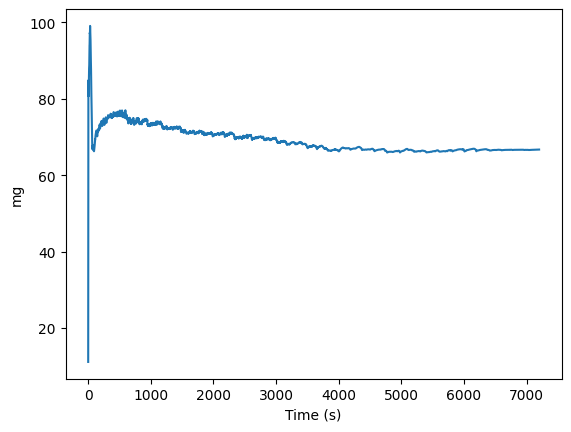

In [85]:
import matplotlib.pyplot as plt

plt.plot(balance["time"], balance["mg"])
plt.xlabel("Time (s)")
plt.ylabel("mg")
plt.show()

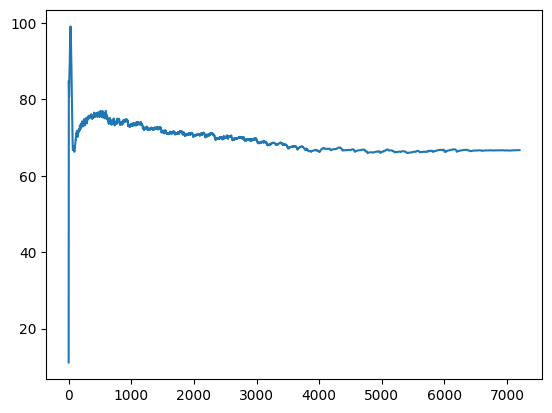

In [86]:
plt.plot(balance["time"], balance["mg"])

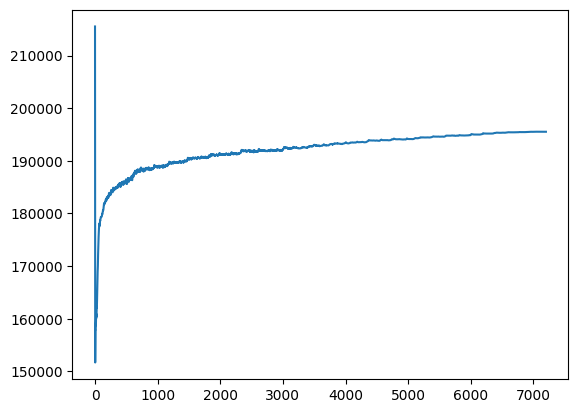

In [87]:
plt.plot(balance["time"], balance["ml"])

time
0.0010       815.870000
10.1739      813.712587
20.1869      811.756012
30.4423      809.734029
40.6916      808.074690
                ...    
7157.4800    507.747309
7167.6500    507.635150
7177.8400    507.523212
7187.9400    507.412254
7198.0100    507.299683
Name: temperature, Length: 706, dtype: float64


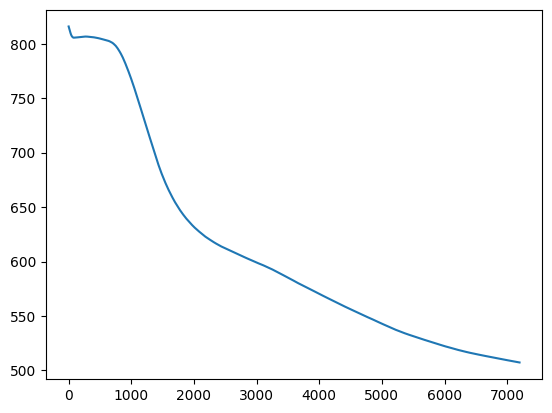

In [88]:
avg_temp = (
    temp.groupby("time")["temperature"]
        .mean()
)
print(avg_temp)
plt.plot(avg_temp.index, avg_temp.values)

In [89]:
from config import SIM7200_DIR, LABEL_FILE
loader = SimulationLoader(SIM7200_DIR)
labels = LabelLoader(LABEL_FILE)
df = labels.data()

print(df.head())
print(df.columns)

                   Psys    Ffuel  Porosity  Dparticle   Alpha   Rflat  \
Simulation No                                                           
0              404411.0  0.82635  0.486025   0.003924  16.839  0.5230   
1              148571.0  0.86185  0.258825   0.002791  18.597  1.8034   
2              411275.0  0.91785  0.423075   0.003737  16.203  0.3646   
3              457139.0  0.97545  0.442825   0.002564  21.129  0.1818   
4              380153.0  0.93225  0.334175   0.001651  27.843  1.0550   

                  Tbed     Decay   Fstruct     Rcake   Topcake   Botcake  \
Simulation No                                                              
0              1512.67  0.008307  1.115375  0.122930  0.715806  0.488859   
1              1253.71  0.007041  0.844125  1.142793  0.853430  0.716177   
2              1549.33  0.003242  0.550125  0.248922  1.254117  0.696887   
3              1286.47  0.007395  0.576375  0.185108  0.592630  0.413072   
4               488.53  0.003832

In [90]:
print(df.columns.tolist())
for c in df.columns:
    print(c)

['Psys', 'Ffuel', 'Porosity', 'Dparticle', 'Alpha', 'Rflat', 'Tbed', 'Decay', 'Fstruct', 'Rcake', 'Topcake', 'Botcake', 'Porcake', 'Partdiacake', 'Hdebris', 'Conclusion', 'Quenching Time', 'Timed Out Conclusion']
Psys
Ffuel
Porosity
Dparticle
Alpha
Rflat
Tbed
Decay
Fstruct
Rcake
Topcake
Botcake
Porcake
Partdiacake
Hdebris
Conclusion
Quenching Time
Timed Out Conclusion


In [91]:
print(balance.columns.tolist())
print(temp.columns.tolist())

['time', 'dt', 'mg', 'mgd', 'ml', 'mld', 'mp', 'mpd', 'mm', 'mmd', 'mc', 'mcd', 'md', 'mdd', 'mlay', 'mlayd', 'eg', 'egd', 'el', 'eld', 'ep', 'epd', 'ec', 'ecd', 'em', 'emd', 'ed', 'edd', 'elay', 'elayd', 'fgini', 'fgin', 'fgouti', 'fgout', 'flini', 'flin', 'flouti', 'flout', 'fdini', 'fdin', 'fdouti', 'fdout', 'flayini', 'flayin', 'flayouti', 'flayout', 'qgini', 'qgin', 'qgouti', 'qgout', 'qlini', 'qlin', 'qlouti', 'qlout', 'qpini', 'qpin', 'qpouti', 'qpout', 'qdini', 'qdin', 'qdouti', 'qdout', 'qlayini', 'qlayin', 'qlayouti', 'qlayout', 'gevi', 'gev', 'qsii', 'qsi', 'qgii', 'qgi', 'qlii', 'qli', 'qsgi', 'qsg', 'qsli', 'qsl', 'qdti', 'qdt', 'qdri', 'qdr', 'qdii', 'qdi', 'qdgi', 'qdg', 'qlaytopi', 'qlaytop', 'powi', 'pow', 'errmgi', 'errmg', 'errmli', 'errml', 'erregi', 'erreg', 'erreli', 'errel', 'errepi', 'errep', 'm(Corium)']
['time', 'particle_id', 'x', 'y', 'z', 'temperature']


## Energy Balance Investigation

To better understand the behavior of the simulations near the end of the transient, an overall energy balance was investigated. Based on discussions with the project supervisor, the following balance equation is expected to hold:

egd + eld + epd =
(qlout - qlin) + (qpout - qpin) + (qgout - qgin) - Power

where:

- `egd`, `eld`, `epd` represent the rate of change of internal energy of the gas, liquid, and particle phases.
- `qlout`, `qlin`, `qpout`, `qpin`, `qgout`, `qgin` are the heat fluxes entering and leaving the computational domain.
- `pow` is the imposed decay heat.

### Residual Definition

The residual of the energy balance was evaluated as

```python
balance["residual"] = (
    balance["energy_rate"]
    - balance["heat_balance"]
)
```

where

```python
balance["energy_rate"] = (
    balance["egd"]
    + balance["eld"]
    + balance["epd"]
)

balance["heat_balance"] = (
    (balance["qlout"] - balance["qlin"])
    + (balance["qpout"] - balance["qpin"])
    + (balance["qgout"] - balance["qgin"])
    - balance["pow"]
)
```

### Observations

The residual exhibits three distinct regions:

- A large transient during the initial timesteps.
- A gradual reduction in magnitude as the simulation progresses.
- Small fluctuations during the final stage of the simulation.

The large residual at the beginning is expected since the system is initially far from equilibrium. As the transient decays, the residual decreases significantly, indicating that the energy balance becomes increasingly well satisfied.

The final 1000 timesteps were analysed separately.

| Statistic | Residual |
|-----------|---------:|
| Mean | -2.34 × 10⁶ |
| Standard deviation | 3.26 × 10⁶ |
| Minimum | -1.45 × 10⁷ |
| Maximum | 2.82 × 10⁷ |

Although the residual is not exactly zero, its magnitude is considerably smaller than the characteristic energy terms, which are typically of the order of 10⁷–10⁸ W. This behaviour is consistent with the expected numerical error associated with a transient simulation approaching a quasi-steady state.

### Additional observations

- The decay heat (`pow`) remains constant throughout the simulation at approximately **1.72 × 10⁷ W**.
- No gas enters the domain (`qgin = 0`).
- No particles enter or leave the domain (`qpin = qpout = 0`).
- The dominant heat transfer mechanisms are therefore:
  - liquid heat transfer (`qlout`, `qlin`)
  - gas heat leaving the system (`qgout`)
  - the constant decay heat source (`pow`)

### Conclusion

The energy balance residual decreases substantially after the initial transient and remains bounded during the later stages of the simulation. This suggests that the numerical solution approaches a quasi-steady regime, although small residual fluctuations remain due to the transient nature of the simulation and numerical discretization.

The energy balance residual, together with its statistical properties over the final portion of the simulation, is a promising candidate for feature engineering in the machine learning model.

In [ ]:
balance["energy_rate"] = (
    balance["egd"]
    + balance["eld"]
    + balance["epd"]
)

balance["heat_balance"] = (
     balance["pow"]- (balance["qlin"] - balance["qlout"])
    + (balance["qpin"] - balance["qpout"])
    + (balance["qgout"] - balance["qgin"])
    
)

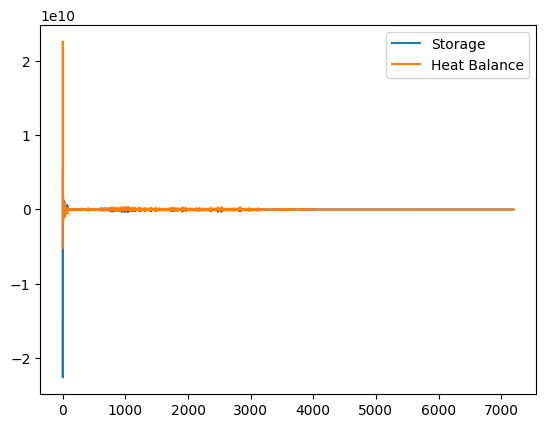

In [181]:
plt.plot(balance["time"], balance["energy_rate"], label="Storage")

plt.plot(balance["time"], balance["heat_balance"], label="Heat Balance")

plt.legend()

## Inference
- the Storage (blue) and Heat Balance (orange) curves almost completely overlap after the initial transient
- theres a very large spike at the beginning (~t=0)
- after that, both the quantities decay and fluctuate close to 0

### Reasoning
- initally, the system adjusts rapidly to the imposed conditions
- later, the rate of energy accumulation becomes much smaller

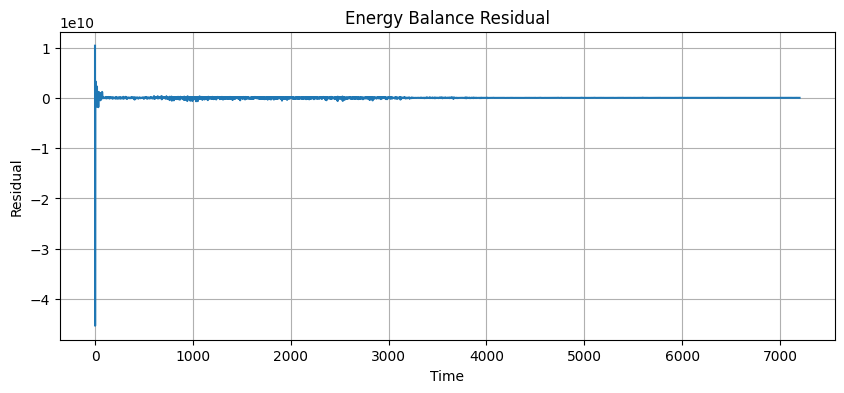

In [182]:
balance["residual1"] = (
    balance["energy_rate"]
    - balance["heat_balance"]
)


plt.figure(figsize=(10,4))
plt.plot(balance["time"], balance["residual1"])
plt.xlabel("Time")
plt.ylabel("Residual")
plt.title("Energy Balance Residual")
plt.grid(True)
plt.show()

In [183]:
print(balance["residual1"].describe())



count    6.023000e+03
mean    -1.041334e+07
std      6.346532e+08
min     -4.531167e+10
25%     -1.229703e+07
50%     -4.339507e+06
75%      6.278057e+06
max      1.036015e+10
Name: residual1, dtype: float64


In [ ]:
tail = balance.tail(1000)

print(tail["residual1"].describe())


count    1.000000e+03
mean    -2.342698e+06
std      3.255950e+06
min     -1.448910e+07
25%     -4.145493e+06
50%     -2.362586e+06
75%     -6.922801e+05
max      2.821135e+07
Name: residual1, dtype: float64
count    1.000000e+03
mean     3.403993e+05
std      2.116652e+05
min      8.562530e+04
25%      2.069393e+05
50%      2.608202e+05
75%      4.020279e+05
max      1.643525e+06
Name: residual2, dtype: float64


## Reasoning to the residual plot trend:
-  we have <i>residual= (storage)- (Heat Balance) </i>, which is close to zero for almost the entire simulation
- the only noticable deviations are during the very early transient

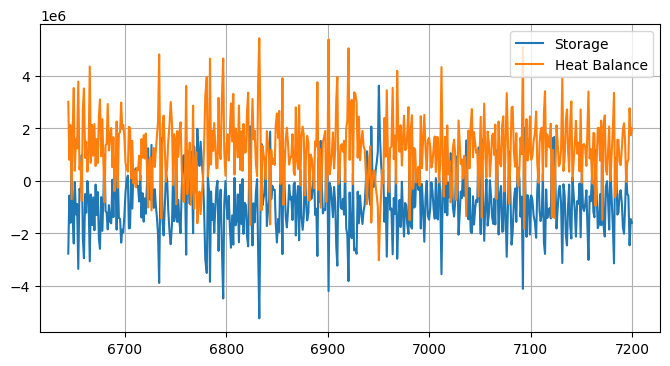

In [185]:
tail = balance.tail(500)

plt.figure(figsize=(8,4))
plt.plot(tail["time"], tail["energy_rate"], label="Storage")
plt.plot(tail["time"], tail["heat_balance"], label="Heat Balance")
plt.legend()
plt.grid(True)

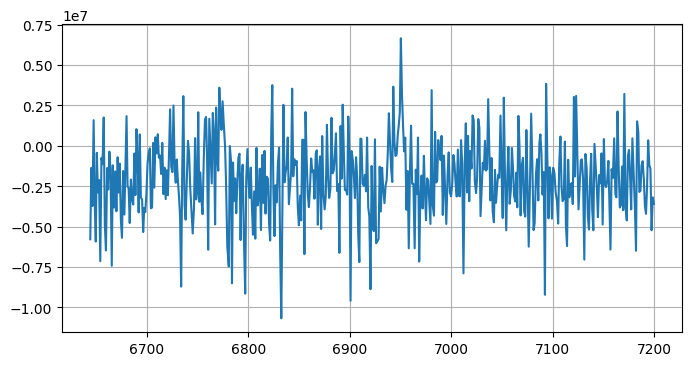

In [186]:
plt.figure(figsize=(8,4))
plt.plot(tail["time"], tail["residual1"])
plt.grid(True)

In [168]:
r1 = balance["energy_rate"] - balance["heat_balance"]
r2 = balance["energy_rate"] + balance["heat_balance"]

print("r1")
print(r1.tail(1000).describe())

print("\nr2")
print(r2.tail(1000).describe())

r1
count    1.000000e+03
mean    -2.342698e+06
std      3.255950e+06
min     -1.448910e+07
25%     -4.145493e+06
50%     -2.362586e+06
75%     -6.922801e+05
max      2.821135e+07
dtype: float64

r2
count    1.000000e+03
mean     3.403993e+05
std      2.116652e+05
min      8.562530e+04
25%      2.069393e+05
50%      2.608202e+05
75%      4.020279e+05
max      1.643525e+06
dtype: float64


In [132]:
tail = balance.tail(10)

In [133]:
a=tail["energy_rate"].sum()
print(a)


-12038109.7882


In [134]:
(tail["energy_rate"]).std()



np.float64(822707.7895845692)

In [135]:
tail["imbalance"].std()

np.float64(57122415.28697357)

In [136]:
tail["imbalance"].sum()

np.float64(-1237026323601.0)

In [137]:
b=tail["imbalance"].sum()
print(b)

-1237026323601.0


In [138]:
print(a-b)

1237014285491.212


In [167]:
storage = (
    balance["egd"]
    + balance["eld"]
    + balance["epd"]
)

heat = (
    balance["qlout"] - balance["qlin"]
    + balance["qpout"] - balance["qpin"]
    + balance["qgout"] - balance["qgin"]
    - balance["pow"]
)

print(storage.corr(heat))

-0.9999910748521744


In [147]:
r1 = storage - heat

r2 = storage + heat

r3 = storage - (
    heat + 2*balance["pow"]
)

r4 = storage + (
    heat + 2*balance["pow"]
)

In [148]:
print(r1,r2,r3,r4)

0       1.036015e+10
1      -4.531167e+10
2      -1.291794e+10
3       1.202694e+09
4       2.621078e+09
            ...     
6018   -1.190303e+06
6019   -1.397484e+06
6020   -5.223323e+06
6021   -3.193670e+06
6022   -3.592888e+06
Length: 6023, dtype: float64 0       2.788325e+07
1       1.279376e+05
2      -6.036520e+04
3      -6.516341e+05
4      -6.802360e+04
            ...     
6018    2.004007e+05
6019    2.329601e+05
6020    3.001072e+05
6021    2.705441e+05
6022    3.890556e+05
Length: 6023, dtype: float64 0       1.032576e+10
1      -4.534606e+10
2      -1.295233e+10
3       1.168306e+09
4       2.586690e+09
            ...     
6018   -3.557777e+07
6019   -3.578495e+07
6020   -3.961079e+07
6021   -3.758113e+07
6022   -3.798035e+07
Length: 6023, dtype: float64 0       6.227071e+07
1       3.451540e+07
2       3.432710e+07
3       3.373583e+07
4       3.431944e+07
            ...     
6018    3.458786e+07
6019    3.462042e+07
6020    3.468757e+07
6021    3.465801e+07
6022    3.

In [149]:
print(balance["pow"].describe())

print(balance["qgout"].describe())
print(balance["qgin"].describe())

print(balance["qlout"].describe())
print(balance["qlin"].describe())

print(balance["qpout"].describe())
print(balance["qpin"].describe())

count        6023.0
mean     17193732.0
std             0.0
min      17193732.0
25%      17193732.0
50%      17193732.0
75%      17193732.0
max      17193732.0
Name: pow, dtype: float64
count    6.023000e+03
mean     2.904857e+07
std      7.306728e+06
min      0.000000e+00
25%      2.533094e+07
50%      2.865965e+07
75%      3.096052e+07
max      1.086042e+08
Name: qgout, dtype: float64
count    6023.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: qgin, dtype: float64
count    6.023000e+03
mean     2.657355e+07
std      3.049836e+08
min      0.000000e+00
25%      1.604766e+07
50%      1.946720e+07
75%      2.009769e+07
max      2.267780e+10
Name: qlout, dtype: float64
count    6.023000e+03
mean     3.305842e+07
std      8.456361e+07
min      4.707097e+06
25%      2.265415e+07
50%      2.512348e+07
75%      3.031093e+07
max      5.148940e+09
Name: qlin, dtype: float64
count    6023.0
mean        0.0
std         0.0


In [170]:
storage = (
    balance["egd"]
    + balance["eld"]
    + balance["epd"]
)

heat = (
    balance["qlout"] - balance["qlin"]
    + balance["qpout"] - balance["qpin"]
    + balance["qgout"] - balance["qgin"]
    - balance["pow"]
)

relative_error = (
    (storage - heat).abs()
    / np.maximum(np.abs(storage), 1.0)
)

print(relative_error.describe())

count    6023.000000
mean        2.287913
std         5.883569
min         0.012364
25%         1.984382
50%         2.023029
75%         2.101194
max       368.760326
dtype: float64


In [153]:
tail = relative_error.tail(500)

print(tail.describe())

count    500.000000
mean       1.505576
std        9.886128
min        0.035492
25%        0.192314
50%        0.301088
75%        0.579300
max      166.722381
dtype: float64


In [42]:
import pandas as pd

metadata = pd.read_csv(
    DATA_DIR/"processed/simulation_metadata_7200.csv"
)

metadata.head()

,Simulation No,Psys,Ffuel,Porosity,Dparticle,Alpha,Rflat,Tbed,Decay,Fstruct,Rcake,Topcake,Botcake,Porcake,Partdiacake,Hdebris,sequence_length,maximum_time
0,0,404411.0,0.82635,0.486025,0.003924,16.839,0.5230,1512.67,0.008307,1.115375,0.122930,0.715806,0.488859,0.182432,0.000844,2.192350,213,2159.540
1,1,148571.0,0.86185,0.258825,0.002791,18.597,1.8034,1253.71,0.007041,0.844125,1.142793,0.853430,0.716177,0.223470,0.001861,1.336405,587,6033.240
2,2,411275.0,0.91785,0.423075,0.003737,16.203,0.3646,1549.33,0.003242,0.550125,0.248922,1.254117,0.696887,0.103698,0.003160,1.846595,712,7198.980
3,3,457139.0,0.97545,0.442825,0.002564,21.129,0.1818,1286.47,0.007395,0.576375,0.185108,0.592630,0.413072,0.305848,0.000449,2.250654,245,2493.700
4,4,380153.0,0.93225,0.334175,0.001651,27.843,1.0550,488.53,0.003832,1.301575,0.436180,0.513966,0.466557,0.079846,0.000250,2.334949,90,914.861


In [43]:
metadata.shape

(5000, 18)

In [44]:
metadata.describe().T

,count,mean,std,min,25%,50%,75%,max
Simulation No,5000.0,2499.500000,1443.520003,0.000000,1249.750000,2499.500000,3749.250000,4999.000000
Psys,5000.0,305000.000000,112594.560259,110039.000000,207519.500000,305000.000000,402480.500000,499961.000000
Ffuel,5000.0,0.750000,0.144352,0.500050,0.625025,0.750000,0.874975,0.999950
Porosity,5000.0,0.375000,0.072176,0.250025,0.312512,0.375000,0.437488,0.499975
Dparticle,5000.0,0.003000,0.001155,0.001000,0.002000,0.003000,0.004000,0.005000
Alpha,5000.0,30.000000,8.661120,15.003000,22.501500,30.000000,37.498500,44.997000
Rflat,5000.0,1.000000,0.577408,0.000200,0.500100,1.000000,1.499900,1.999800
Tbed,5000.0,1050.000000,375.315201,400.130000,725.065000,1050.000000,1374.935000,1699.870000
Decay,5000.0,0.006500,0.002021,0.003001,0.004750,0.006500,0.008250,0.009999
Fstruct,5000.0,1.125000,0.505232,0.250175,0.687588,1.125000,1.562412,1.999825


In [45]:
metadata.isna().sum()

Simulation No      0
Psys               0
Ffuel              0
Porosity           0
Dparticle          0
Alpha              0
Rflat              0
Tbed               0
Decay              0
Fstruct            0
Rcake              0
Topcake            0
Botcake            0
Porcake            0
Partdiacake        0
Hdebris            0
sequence_length    0
maximum_time       0
dtype: int64

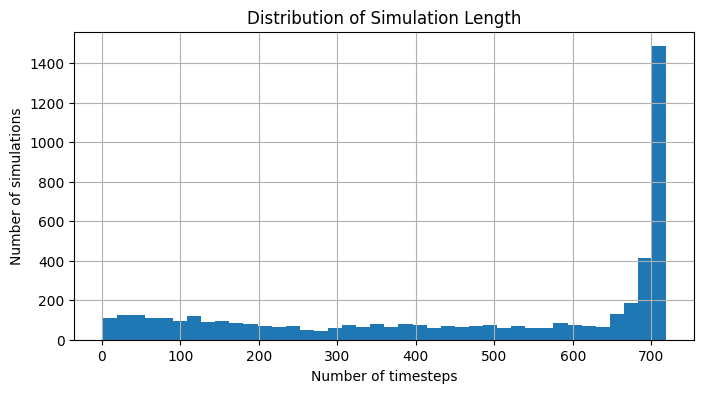

In [46]:
plt.figure(figsize=(8, 4))

plt.hist(
    metadata["sequence_length"],
    bins=40
)

plt.xlabel("Number of timesteps")
plt.ylabel("Number of simulations")
plt.title("Distribution of Simulation Length")

plt.grid(True)
plt.show()

In [47]:
metadata["sequence_length"].describe()

count    5000.000000
mean      472.337200
std       250.800104
min         1.000000
25%       228.000000
50%       578.000000
75%       706.000000
max       719.000000
Name: sequence_length, dtype: float64

In [48]:
metadata["sequence_length"].sort_values().head(20)

990     1
4825    1
62      1
1598    1
509     1
113     1
4766    1
1609    1
3272    1
2859    1
2808    1
941     1
2661    1
971     1
4007    1
3244    1
2536    1
1313    1
3745    1
2626    1
Name: sequence_length, dtype: int64

we see a bunch of simulation lengths only being 1, we now need to investigate how this works so that we can find a cutoff length for our model and remove those simulations that span shorter than the cutoff

In [49]:
#count of simulations with length less than 1,5,10, and 20
print("Total simulations:", len(metadata))

print("\nSequence length <= 1:")
print((metadata["sequence_length"] <= 1).sum())

print("\nSequence length <= 5:")
print((metadata["sequence_length"] <= 5).sum())

print("\nSequence length <= 10:")
print((metadata["sequence_length"] <= 10).sum())

print("\nSequence length <= 20:")
print((metadata["sequence_length"] <= 20).sum())

Total simulations: 5000

Sequence length <= 1:
39

Sequence length <= 5:
42

Sequence length <= 10:
63

Sequence length <= 20:
120


In [50]:
#find those simulations
short_cases = metadata[
    metadata["sequence_length"] <= 10
][
    [
        "Simulation No",
        "sequence_length",
        "maximum_time"
    ]
].sort_values("sequence_length")

short_cases.head(30)

,Simulation No,sequence_length,maximum_time
62,62,1,0.001
113,113,1,0.001
241,241,1,0.001
270,270,1,0.001
509,509,1,0.001
331,331,1,0.001
807,807,1,0.001
568,568,1,0.001
848,848,1,0.001
849,849,1,0.001


In [51]:
metadata[
    metadata["sequence_length"] <= 5
][
    ["Simulation No", "sequence_length", "maximum_time"]
].sort_values("sequence_length")

,Simulation No,sequence_length,maximum_time
62,62,1,0.0010
113,113,1,0.0010
241,241,1,0.0010
270,270,1,0.0010
331,331,1,0.0010
509,509,1,0.0010
568,568,1,0.0010
807,807,1,0.0010
849,849,1,0.0010
829,829,1,0.0010


In [52]:
import numpy as np

metadata["log_sequence_length"] = np.log1p(
    metadata["sequence_length"]
)

metadata["length_group"] = pd.qcut(
    metadata["log_sequence_length"],
    q=5,
    labels=False,
    duplicates="drop"
)

metadata["length_group"].value_counts().sort_index()

length_group
0    1000
1    1002
2    1001
3     997
4    1000
Name: count, dtype: int64

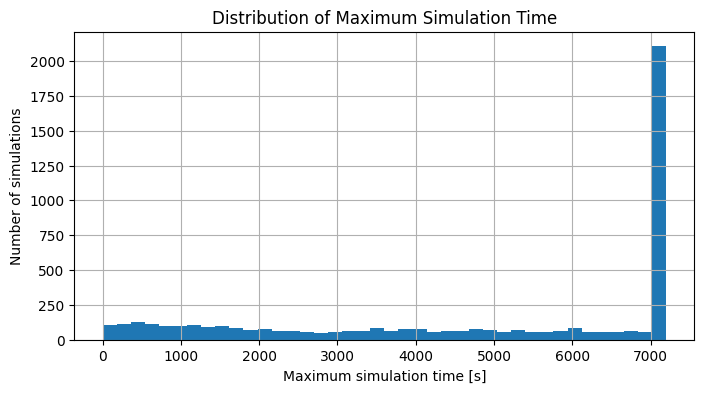

In [53]:
plt.figure(figsize=(8, 4))

plt.hist(
    metadata["maximum_time"],
    bins=40
)

plt.xlabel("Maximum simulation time [s]")
plt.ylabel("Number of simulations")
plt.title("Distribution of Maximum Simulation Time")

plt.grid(True)
plt.show()

In [54]:
metadata[
    ["sequence_length", "maximum_time"]
].describe()

,sequence_length,maximum_time
count,5000.000000,5000.000000
mean,472.337200,4828.713466
std,250.800104,2569.218419
min,1.000000,0.001000
25%,228.000000,2325.295000
50%,578.000000,5874.625000
75%,706.000000,7194.082500
max,719.000000,7200.000000


In [55]:
print(
    "Simulations reaching maximum time:",
    (metadata["maximum_time"] == metadata["maximum_time"].max()).sum()
)

print(
    "Simulations stopping earlier:",
    (metadata["maximum_time"] < metadata["maximum_time"].max()).sum()
)

Simulations reaching maximum time: 61
Simulations stopping earlier: 4939


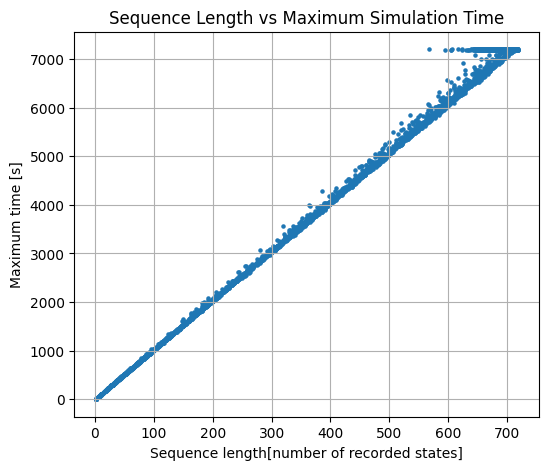

In [56]:
plt.figure(figsize=(6, 5))

plt.scatter(
    metadata["sequence_length"],
    metadata["maximum_time"],
    s=5
)

plt.xlabel("Sequence length[number of recorded states]")
plt.ylabel("Maximum time [s]")
plt.title("Sequence Length vs Maximum Simulation Time")

plt.grid(True)
plt.show()

In [57]:
metadata_clean[
    ["sequence_length", "maximum_time"]
].corr()

NameError: name 'metadata_clean' is not defined

In [41]:
plt.figure(figsize=(8, 5))

plt.scatter(
    metadata_clean["sequence_length"],
    metadata_clean["maximum_time"],
    alpha=0.4
)

plt.xlabel("Sequence length [number of states]")
plt.ylabel("Maximum simulation time [s]")
plt.title("Sequence Length vs Maximum Simulation Time")

plt.grid(True)
plt.show()

NameError: name 'metadata_clean' is not defined

<Figure size 800x500 with 0 Axes>

## 1. check input ranges

In [40]:
input_columns = [
    "Psys",
    "Ffuel",
    "Porosity",
    "Dparticle",
    "Alpha",
    "Rflat",
    "Tbed",
    "Decay",
    "Fstruct",
    "Rcake",
    "Topcake",
    "Botcake",
    "Porcake",
    "Partdiacake",
    "Hdebris",
]

metadata[input_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Psys,5000.0,305000.000000,112594.560259,110039.000000,207519.500000,305000.000000,402480.500000,499961.000000
Ffuel,5000.0,0.750000,0.144352,0.500050,0.625025,0.750000,0.874975,0.999950
Porosity,5000.0,0.375000,0.072176,0.250025,0.312512,0.375000,0.437488,0.499975
Dparticle,5000.0,0.003000,0.001155,0.001000,0.002000,0.003000,0.004000,0.005000
Alpha,5000.0,30.000000,8.661120,15.003000,22.501500,30.000000,37.498500,44.997000
Rflat,5000.0,1.000000,0.577408,0.000200,0.500100,1.000000,1.499900,1.999800
Tbed,5000.0,1050.000000,375.315201,400.130000,725.065000,1050.000000,1374.935000,1699.870000
Decay,5000.0,0.006500,0.002021,0.003001,0.004750,0.006500,0.008250,0.009999
Fstruct,5000.0,1.125000,0.505232,0.250175,0.687588,1.125000,1.562412,1.999825
Rcake,5000.0,0.550718,0.358044,0.001711,0.260775,0.488434,0.787456,2.036996


In [41]:
metadata[input_columns].nunique().sort_values()

Psys           5000
Ffuel          5000
Porosity       5000
Dparticle      5000
Alpha          5000
Rflat          5000
Tbed           5000
Decay          5000
Fstruct        5000
Rcake          5000
Topcake        5000
Botcake        5000
Porcake        5000
Partdiacake    5000
Hdebris        5000
dtype: int64

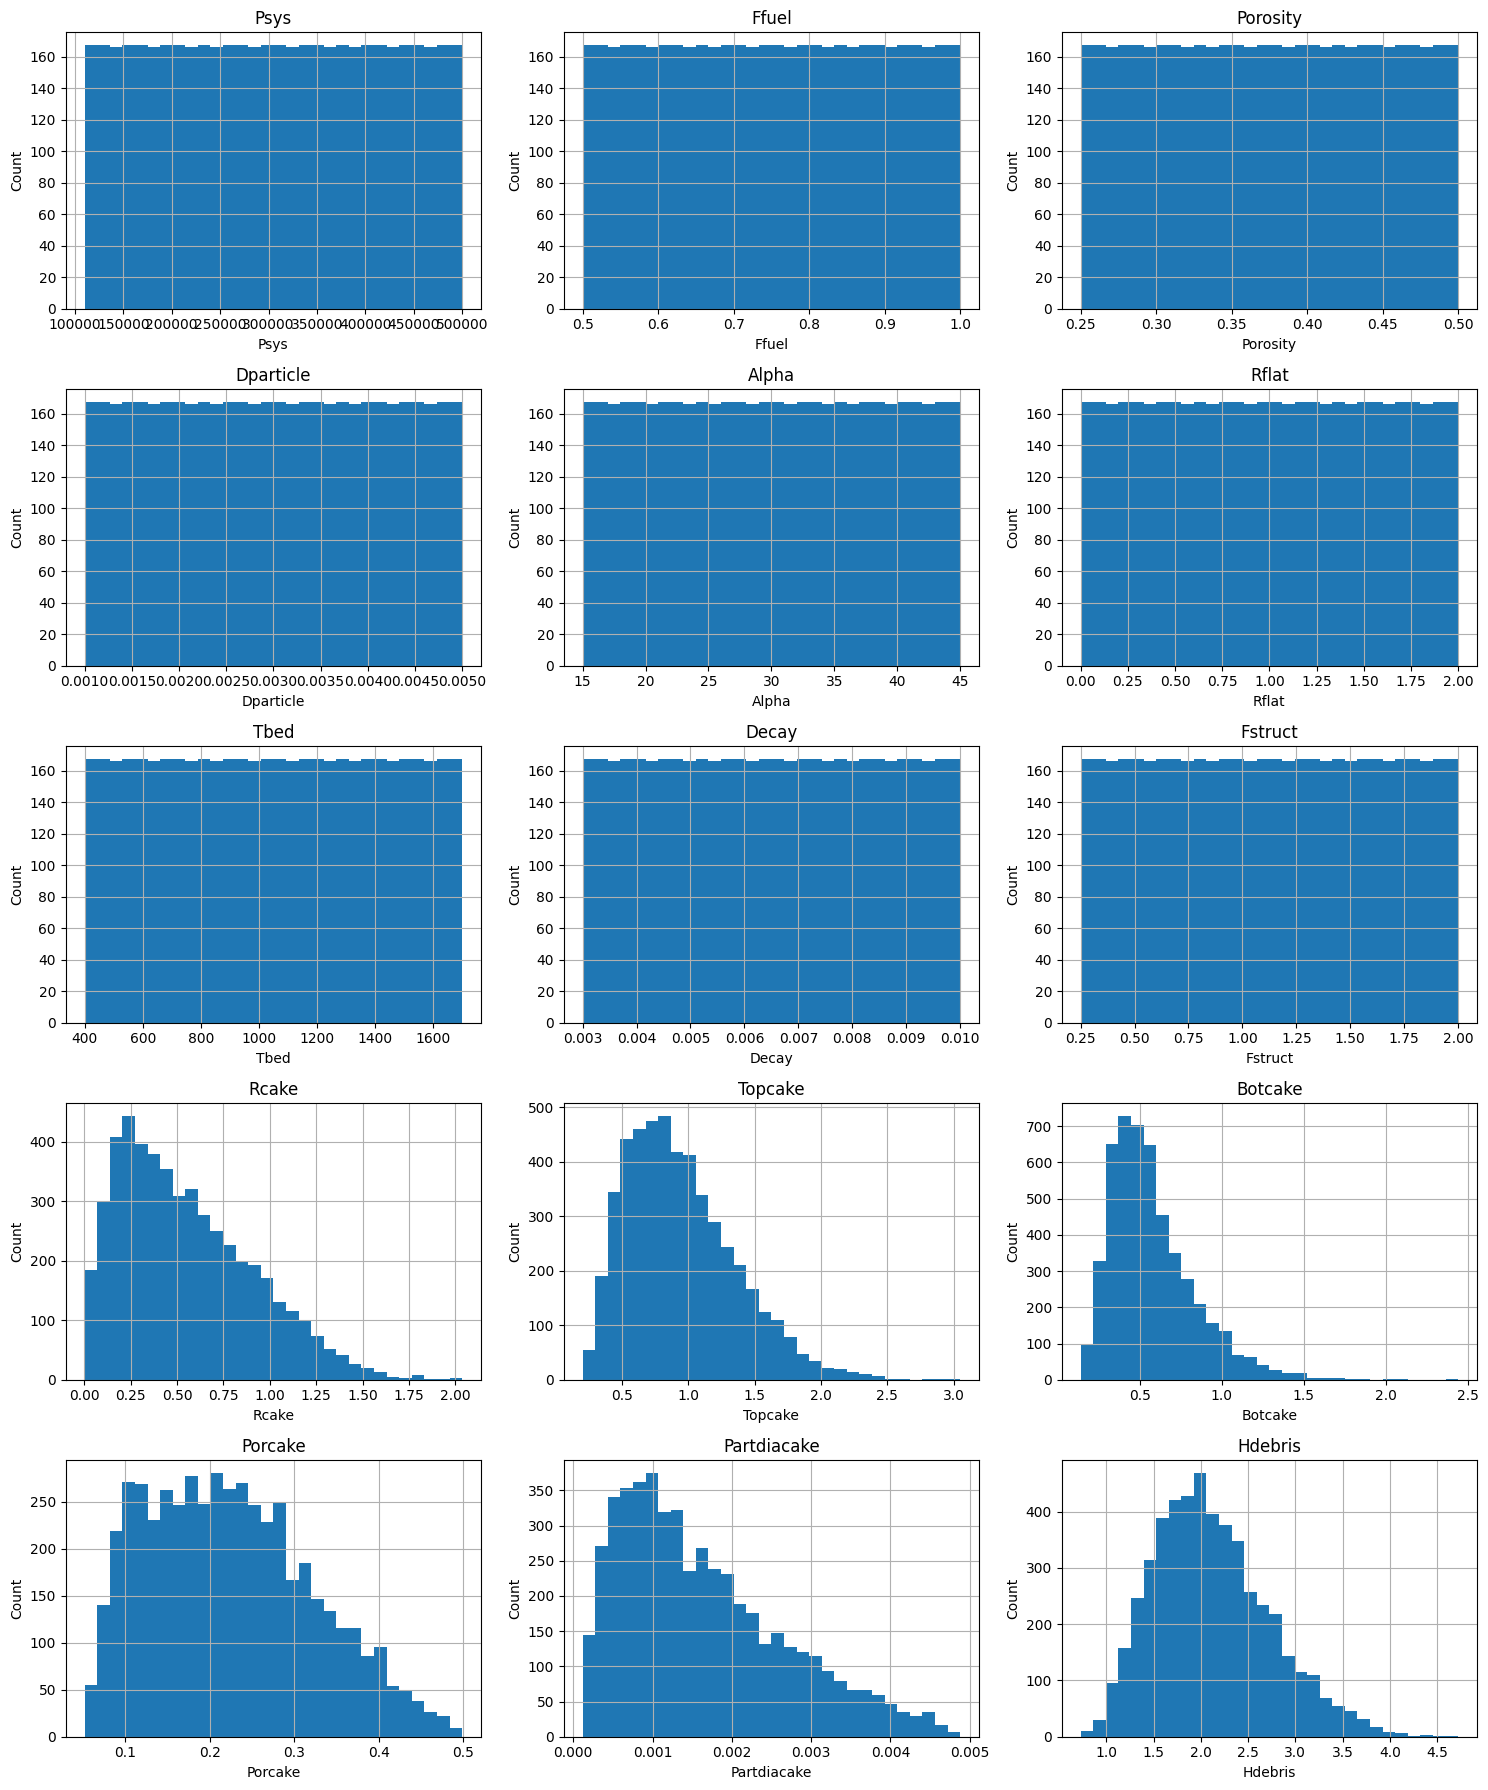

In [42]:
fig, axes = plt.subplots(
    5, 3,
    figsize=(15, 18)
)

for ax, column in zip(axes.flat, input_columns):

    ax.hist(
        metadata[column],
        bins=30
    )

    ax.set_title(column)
    ax.set_xlabel(column)
    ax.set_ylabel("Count")
    ax.grid(True)

plt.tight_layout()
plt.show()

### Input Parameter Distribution

The 5000 simulations cover a 15-dimensional input parameter space. All 15 parameters contain 5000 unique values, indicating that none of the input parameters is constant across the dataset.

The distributions of the input parameters are not identical. Several parameters, including Psys, Ffuel, Porosity, Dparticle, Alpha, Rflat, Tbed, Decay, and Fstruct, are approximately uniformly distributed over their respective ranges. In contrast, several debris-bed and cake-related parameters, particularly Rcake, Topcake, Botcake, Partdiacake, and Hdebris, exhibit non-uniform distributions with varying degrees of skewness.

This indicates that the simulation dataset provides broad coverage of the input parameter space, although the sampling density is not uniform for all parameters. The non-uniform distributions should be considered when constructing the training, validation, and test sets to ensure that the model is evaluated across the relevant range of physical conditions.

In [44]:
metadata["time_per_step"] = (
    metadata["maximum_time"] /
    metadata["sequence_length"]
)

metadata["time_per_step"].describe()

count    5000.000000
mean       10.122302
std         0.923964
min         0.001000
25%        10.105197
50%        10.155861
75%        10.240535
max        12.670282
Name: time_per_step, dtype: float64

In [45]:
simid = 0
sim = loader.load_simulation(simid)

balance = sim["balance"]
temperature = sim["temperature"]

print(balance.shape)
print(temperature.shape)

/home/ikeaprash/project/data/7200 sec Run/00000_balance_readable.xlsx
(1879, 101)
(171678, 6)


In [47]:
print(balance.columns.tolist())
print(temperature.columns.tolist())

['time', 'dt', 'mg', 'mgd', 'ml', 'mld', 'mp', 'mpd', 'mm', 'mmd', 'mc', 'mcd', 'md', 'mdd', 'mlay', 'mlayd', 'eg', 'egd', 'el', 'eld', 'ep', 'epd', 'ec', 'ecd', 'em', 'emd', 'ed', 'edd', 'elay', 'elayd', 'fgini', 'fgin', 'fgouti', 'fgout', 'flini', 'flin', 'flouti', 'flout', 'fdini', 'fdin', 'fdouti', 'fdout', 'flayini', 'flayin', 'flayouti', 'flayout', 'qgini', 'qgin', 'qgouti', 'qgout', 'qlini', 'qlin', 'qlouti', 'qlout', 'qpini', 'qpin', 'qpouti', 'qpout', 'qdini', 'qdin', 'qdouti', 'qdout', 'qlayini', 'qlayin', 'qlayouti', 'qlayout', 'gevi', 'gev', 'qsii', 'qsi', 'qgii', 'qgi', 'qlii', 'qli', 'qsgi', 'qsg', 'qsli', 'qsl', 'qdti', 'qdt', 'qdri', 'qdr', 'qdii', 'qdi', 'qdgi', 'qdg', 'qlaytopi', 'qlaytop', 'powi', 'pow', 'errmgi', 'errmg', 'errmli', 'errml', 'erregi', 'erreg', 'erreli', 'errel', 'errepi', 'errep', 'm(Corium)']
['time', 'particle_id', 'x', 'y', 'z', 'temperature']


In [52]:
print(balance.head())
print(balance.describe().T)

      time       dt         mg        mgd          ml         mld         mp  \
0  0.00100  0.00100   17.71120    0.35583  198871.960  13398.9430  236371.72   
1  1.00324  0.00522  246.91085 -112.71521  115985.050 -54436.1590  236371.72   
2  2.10965  0.12617  120.06423  -30.12623   93769.713  -6668.3726  236371.72   
3  3.23636  0.31396  120.94983    6.18819   88746.383  -3874.2965  236371.72   
4  4.60772  0.54252  128.23167    4.28949   84416.164  -2787.9511  236371.72   

   mpd  mm  mmd  ...    errmg     errmli      errml        erregi  \
0    0   0    0  ... -0.35583    0.16312  163.12139       4.62334   
1    0   0    0  ...  2.23215  -97.92820 -442.06304  -34836.86200   
2    0   0    0  ... -0.18058 -161.64460  -12.32741  -96144.34400   
3    0   0    0  ... -0.13268 -170.46134   -6.57351 -260235.87000   
4    0   0    0  ... -0.18021 -178.06628   -5.09187 -555516.78000   

         erreg       erreli         errel        errepi         errep  \
0    4623.3374   -8398.4547 -8.

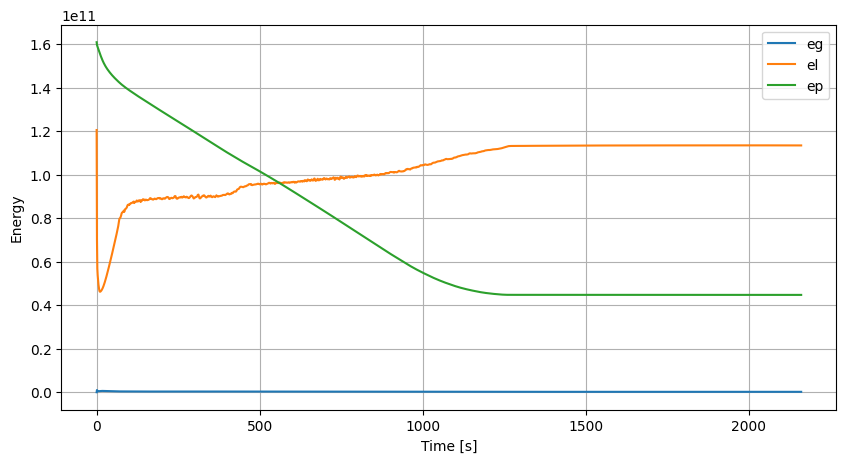

In [48]:
plt.figure(figsize=(10, 5))

plt.plot(
    balance["time"],
    balance["eg"],
    label="eg"
)

plt.plot(
    balance["time"],
    balance["el"],
    label="el"
)

plt.plot(
    balance["time"],
    balance["ep"],
    label="ep"
)

plt.xlabel("Time [s]")
plt.ylabel("Energy")
plt.legend()
plt.grid(True)

plt.show()

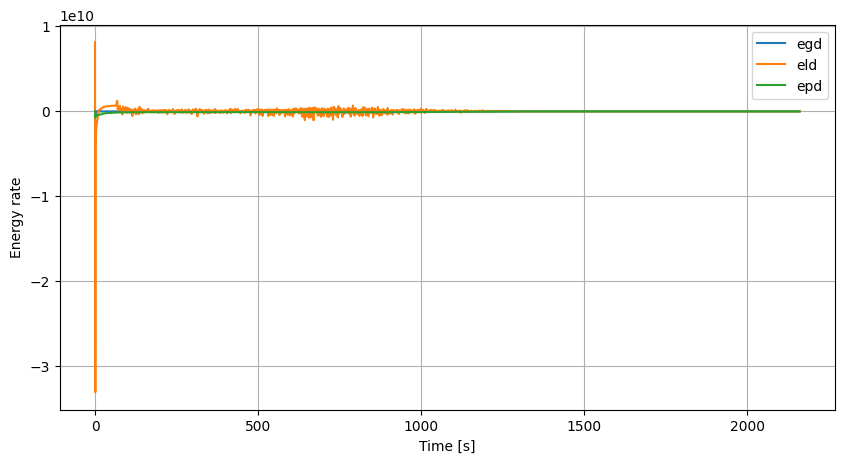

In [49]:
plt.figure(figsize=(10, 5))

plt.plot(balance["time"], balance["egd"], label="egd")
plt.plot(balance["time"], balance["eld"], label="eld")
plt.plot(balance["time"], balance["epd"], label="epd")

plt.xlabel("Time [s]")
plt.ylabel("Energy rate")
plt.legend()
plt.grid(True)

plt.show()

In [50]:
print(temperature["particle_id"].nunique())
print(temperature["time"].nunique())
print(temperature.groupby("time").size().describe())

806
213
count    213.0
mean     806.0
std        0.0
min      806.0
25%      806.0
50%      806.0
75%      806.0
max      806.0
dtype: float64


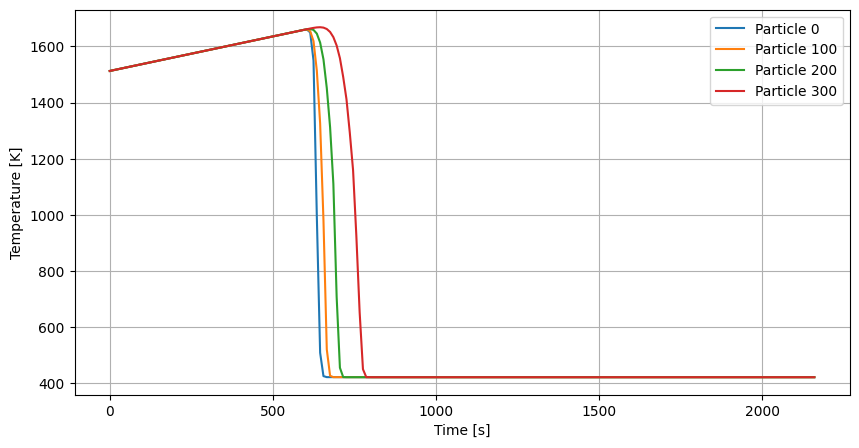

In [51]:
particle_ids = [0, 100, 200, 300]

plt.figure(figsize=(10, 5))

for pid in particle_ids:

    particle = temperature[
        temperature["particle_id"] == pid
    ]

    plt.plot(
        particle["time"],
        particle["temperature"],
        label=f"Particle {pid}"
    )

plt.xlabel("Time [s]")
plt.ylabel("Temperature [K]")
plt.legend()
plt.grid(True)

plt.show()

In [53]:
print(balance["time"].nunique())
print(balance["time"].min(), balance["time"].max())
print(balance["time"].diff().describe())

1879
0.001 2161.0033
count    1878.000000
mean        1.150693
std         0.166397
min         1.000200
25%         1.042832
50%         1.100300
75%         1.189560
max         2.191760
Name: time, dtype: float64


In [54]:
particle_times = (
    temperature["time"]
    .drop_duplicates()
    .sort_values()
)

print(len(particle_times))
print(particle_times.min(), particle_times.max())
print(particle_times.diff().describe())

213
0.001 2159.54
count    212.000000
mean      10.186505
std        0.246809
min       10.000000
25%       10.050000
50%       10.100000
75%       10.207750
max       11.320000
Name: time, dtype: float64


In [55]:
balance.describe().T[
    ["mean", "std", "min", "max"]
]

,mean,std,min,max
time,1.107951e+03,6.080465e+02,1.000000e-03,2.161003e+03
dt,3.512139e-01,3.399235e-01,1.000000e-03,1.663120e+00
mg,1.137404e+02,1.555442e+01,1.771120e+01,2.469109e+02
mgd,-6.211097e-02,2.785837e+00,-1.127152e+02,8.724050e+00
ml,1.703328e+05,1.956164e+04,7.630581e+04,1.988720e+05
...,...,...,...,...
erreli,-8.694229e+06,4.389922e+06,-1.341682e+07,-8.398455e+03
errel,-8.907606e+03,1.949758e+05,-8.398455e+06,2.143682e+05
errepi,3.392589e+06,1.229020e+06,-7.799600e-01,4.465590e+06
errep,2.163406e+03,7.492704e+03,-4.178235e+04,1.207907e+05


In [56]:
balance.std(numeric_only=True).sort_values().head(20)

mpd       0.0
mlay      0.0
mdd       0.0
md        0.0
mcd       0.0
mc        0.0
mmd       0.0
mm        0.0
mlayd     0.0
emd       0.0
ed        0.0
edd       0.0
elay      0.0
elayd     0.0
ecd       0.0
ec        0.0
fgini     0.0
fgin      0.0
em        0.0
qdouti    0.0
dtype: float64

In [57]:
balance.std(numeric_only=True).sort_values(ascending=False).head(20)

qgouti    5.920864e+10
qlini     5.331147e+10
qsii      4.188278e+10
ep        3.244091e+10
qlouti    3.121070e+10
powi      1.593550e+10
el        1.212241e+10
qsgi      5.424077e+09
eld       8.149655e+08
qlout     7.788253e+08
qlii      6.363521e+08
qdii      3.321960e+08
qlin      2.260282e+08
qgout     7.809763e+07
eg        7.153404e+07
epd       6.113474e+07
qsi       4.658566e+07
qsg       1.681451e+07
egd       1.061973e+07
erregi    7.470965e+06
dtype: float64

m corium is essentially constant

## Duration Prediction Baseline

As a first prediction task, the simulation duration was modeled using the static input parameters of each simulation.

The dataset initially contained 5000 simulations. Simulations with fewer than 10 timesteps were removed because such short trajectories do not contain sufficient temporal information for meaningful time-series modeling. This resulted in 4945 simulations.

The simulations were divided into training, validation, and test sets at the **simulation level**, rather than at the individual timestep level. The split was stratified according to trajectory length to ensure that short and long simulations were represented in all three subsets.

### Input

The duration model uses the 15 static simulation parameters:

- Psys
- Ffuel
- Porosity
- Dparticle
- Alpha
- Rflat
- Tbed
- Decay
- Fstruct
- Rcake
- Topcake
- Botcake
- Porcake
- Partdiacake
- Hdebris

### Target

The target variable was defined as:

`log1p(sequence_length)`

The logarithmic transformation was used because the distribution of simulation lengths is strongly skewed, with a large concentration of simulations close to the maximum duration.

Two quantile regression models were trained:

- **P50 model:** predicts the median simulation length
- **P75 model:** predicts the 75th percentile of simulation length

### Results

#### P50 model

- MAE in log space: **0.275**
- RMSE in log space: **0.449**
- MAE in original sequence length: **92.6 timesteps**
- P50 coverage: **50.7%**
- Median absolute percentage error (MdAPE): **16.3%**

#### P75 model

- MAE in log space: **0.316**
- MAE in original sequence length: **95.8 timesteps**
- P75 coverage: **68.9%**
- Median absolute percentage error (MdAPE): **14.6%**

The P50 model is well calibrated, with approximately 50% of the actual sequence lengths falling below the predicted P50 value. The P75 model currently underestimates the desired 75% coverage, achieving approximately 69%.

### Dependence on Simulation Duration

The prediction error was also evaluated for different ranges of actual sequence length.

| Actual sequence length | Number of cases | MAE [timesteps] | MdAPE |
|---|---:|---:|---:|
| 0–50 | 24 | 45.8 | 66.6% |
| 50–100 | 33 | 115.3 | 70.9% |
| 100–200 | 49 | 82.5 | 29.4% |
| 200–300 | 32 | 85.6 | 21.5% |
| 300–500 | 75 | 80.0 | 17.4% |
| 500–650 | 66 | 103.3 | 14.7% |
| 650–750 | 216 | 98.8 | 8.2% |

The model performs considerably better in relative terms for long simulations. The MdAPE decreases from approximately 67–71% for simulations shorter than 100 timesteps to only 8.2% for simulations between 650 and 750 timesteps.

The large relative errors for short simulations are partly caused by the sensitivity of relative error to small target values. For example, an absolute error of 50 timesteps corresponds to a 100% relative error for a 50-timestep simulation, but only about 7% for a 700-timestep simulation.

Overall, the duration prediction task appears to be **learnable from the static simulation parameters**, although short-duration and early-terminating simulations remain considerably more difficult to predict accurately.

This provides a baseline for the next stage of the workflow: **prediction of the maximum simulation time**.

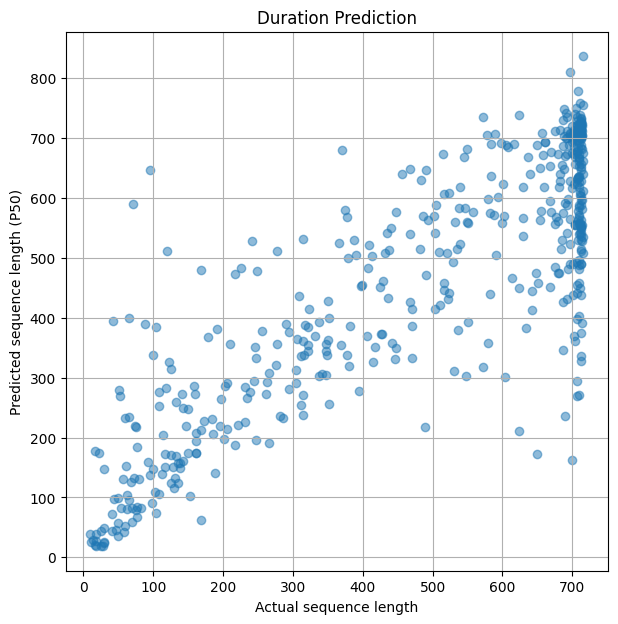

In [5]:
results = pd.read_csv(
    DATA_DIR/"processed/duration_predictions.csv"
)

plt.figure(figsize=(7, 7))

plt.scatter(
    results["sequence_length"],
    results["predicted_length_p50"],
    alpha=0.5
)

plt.xlabel("Actual sequence length")
plt.ylabel("Predicted sequence length (P50)")
plt.title("Duration Prediction")

plt.grid(True)
plt.show()

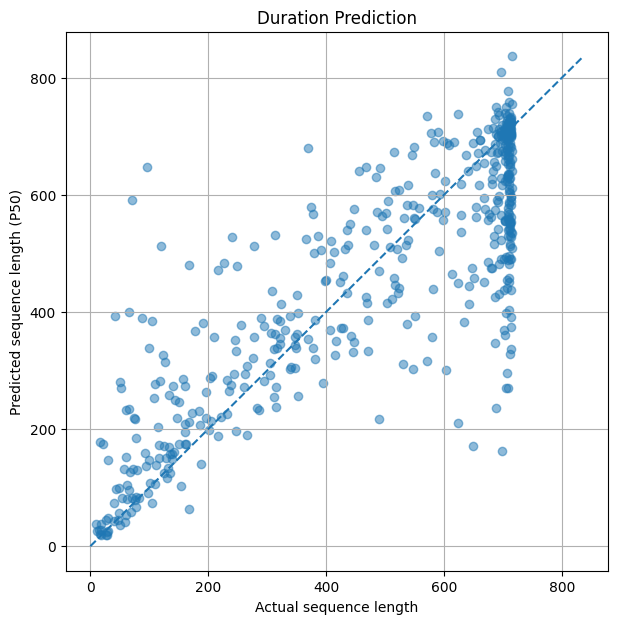

In [6]:
max_value = max(
    results["sequence_length"].max(),
    results["predicted_length_p50"].max()
)

plt.figure(figsize=(7, 7))

plt.scatter(
    results["sequence_length"],
    results["predicted_length_p50"],
    alpha=0.5
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.xlabel("Actual sequence length")
plt.ylabel("Predicted sequence length (P50)")
plt.title("Duration Prediction")

plt.grid(True)
plt.show()

In [7]:
metadata = pd.read_csv(
    DATA_DIR/ "processed/simulation_metadata_7200_clean.csv"
)

splits = pd.read_csv(
    DATA_DIR/ "processed/simulation_splits.csv"
)

print("Clean metadata:", len(metadata))
print("Split file:", len(splits))

print(
    "Metadata IDs:",
    metadata["Simulation No"].nunique()
)

print(
    "Split IDs:",
    splits["Simulation No"].nunique()
)

print(
    "Missing from splits:",
    set(metadata["Simulation No"]) - set(splits["Simulation No"])
)

print(
    "Extra in splits:",
    set(splits["Simulation No"]) - set(metadata["Simulation No"])
)

Clean metadata: 4945
Split file: 4945
Metadata IDs: 4945
Split IDs: 4945
Missing from splits: set()
Extra in splits: set()


In [8]:
coverage_p75 = (
    results["sequence_length"]
    <= results["predicted_length_p75"]
).mean()

print(f"P75 coverage: {coverage_p75:.3f}")

P75 coverage: 0.689


In [9]:
coverage_p50 = (
    results["sequence_length"]
    <= results["predicted_length_p50"]
).mean()

print(f"P50 coverage: {coverage_p50:.3f}")

P50 coverage: 0.507


In [10]:
#find the worst predictions
results.sort_values(
    "relative_error_p50",
    ascending=False
)[
    [
        "Simulation No",
        "sequence_length",
        "predicted_length_p50",
        "predicted_length_p75",
        "relative_error_p50",
    ]
].head(20)

,Simulation No,sequence_length,predicted_length_p50,predicted_length_p75,relative_error_p50
360,3710,16,177.639319,172.424496,10.102457
234,2374,42,393.921385,342.695215,8.379081
16,135,71,590.584889,474.131699,7.318097
488,4949,22,174.819146,294.501825,6.946325
438,4424,96,647.301150,685.875557,5.742720
44,501,65,400.327537,379.729146,5.158885
241,2445,51,279.979309,227.131125,4.489790
482,4908,52,269.518201,189.915451,4.183042
222,2232,30,146.729880,171.561625,3.890996
66,688,88,389.775283,313.090077,3.429265


In [11]:
results.sort_values(
    "relative_error_p75",
    ascending=False
)[
    [
        "Simulation No",
        "sequence_length",
        "predicted_length_p50",
        "predicted_length_p75",
        "relative_error_p75",
    ]
].head(20)

,Simulation No,sequence_length,predicted_length_p50,predicted_length_p75,relative_error_p75
488,4949,22,174.819146,294.501825,12.386447
360,3710,16,177.639319,172.424496,9.776531
359,3708,10,38.367785,87.540790,7.754079
234,2374,42,393.921385,342.695215,7.159410
438,4424,96,647.301150,685.875557,6.144537
153,1552,61,153.059780,416.307365,5.824711
16,135,71,590.584889,474.131699,5.677911
44,501,65,400.327537,379.729146,4.841987
222,2232,30,146.729880,171.561625,4.718721
61,662,18,38.666287,102.343554,4.685753


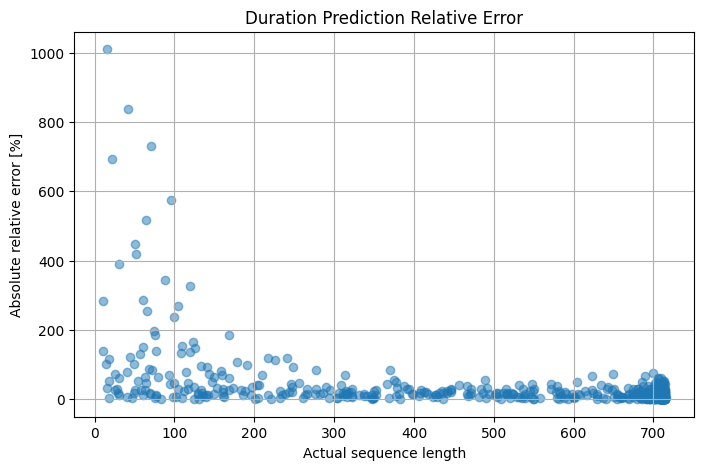

In [12]:
plt.figure(figsize=(8, 5))

plt.scatter(
    results["sequence_length"],
    results["relative_error_p50"] * 100,
    alpha=0.5
)

plt.xlabel("Actual sequence length")
plt.ylabel("Absolute relative error [%]")
plt.title("Duration Prediction Relative Error")

plt.grid(True)
plt.show()

the biggest relative errors are <b> strongly concentrated at short sequence lengths </b>
For simulations with:

- sequence_length < 100: relative errors can exceed 1000%
- sequence_length ≈ 100–200: errors are generally much smaller, but there are still some large outliers
- sequence_length > 300: most errors are roughly <100%
- sequence_length ≈ 700: the majority are relatively close to zero

So the huge mean relative error of 39.1% is <b> not representative of the model's performance across the majority of the dataset </b> . It is being driven heavily by the short-duration simulations.

an important thing we learned from this:
<b> Duration prediction is substantially more difficult for early-terminating simulations than for simulations approaching the maximum runtime.</b>

In [13]:
bins = [0, 50, 100, 200, 300, 500, 650, 750]

results["duration_bin"] = pd.cut(
    results["sequence_length"],
    bins=bins
)

grouped = results.groupby(
    "duration_bin",
    observed=True
)

summary = grouped.apply(
    lambda x: pd.Series({
        "N": len(x),
        "MAE": np.mean(
            np.abs(
                x["predicted_length_p50"]
                - x["sequence_length"]
            )
        ),
        "MdAPE": np.median(
            np.abs(
                x["predicted_length_p50"]
                - x["sequence_length"]
            )
            / x["sequence_length"]
        ) * 100,
    })
)

summary

/tmp/ipykernel_1294147/3168229087.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = grouped.apply(


,N,MAE,MdAPE
duration_bin,,,
"(0, 50]",24.0,45.827602,66.571825
"(50, 100]",33.0,115.329998,70.910854
"(100, 200]",49.0,82.509304,29.436557
"(200, 300]",32.0,85.560711,21.515953
"(300, 500]",75.0,80.035656,17.370438
"(500, 650]",66.0,103.279291,14.741214
"(650, 750]",216.0,98.801367,8.191219


In [23]:
metadata_clean = metadata[
    metadata["sequence_length"] >= MIN_SEQUENCE_LEN
].copy()
metadata_clean["maximum_time"].describe()

count    4945.000000
mean     4882.221260
std      2532.582281
min        91.051800
25%      2441.390000
50%      5944.440000
75%      7194.170000
max      7200.000000
Name: maximum_time, dtype: float64

In [16]:
print("Shortest simulations:")
print(
    metadata_clean[
        ["Simulation No", "maximum_time", "sequence_length"]
    ]
    .sort_values("maximum_time")
    .head(20)
)

print("\nLongest simulations:")
print(
    metadata_clean[
        ["Simulation No", "maximum_time", "sequence_length"]
    ]
    .sort_values("maximum_time", ascending=False)
    .head(20)
)

Shortest simulations:
      Simulation No  maximum_time  sequence_length
260             263       91.0518               10
1207           1228       91.0847               10
2923           2959       91.3200               10
3703           3746       91.9279               10
3666           3708       93.1302               10
1288           1310       93.3117               10
4903           4958       93.5732               10
2657           2688       95.3302               10
2554           2583      101.7030               11
1065           1086      101.9980               11
4603           4653      104.1880               11
2341           2368      104.3640               11
734             744      105.3340               11
3419           3460      106.7380               11
4410           4458      114.5660               12
4374           4421      115.3560               12
1856           1881      116.8690               12
2703           2734      117.0540               12
1983     

In [17]:
for threshold in [7000, 7100, 7150, 7190, 7199]:
    count = (
        metadata_clean["maximum_time"] >= threshold
    ).sum()

    percentage = (
        count / len(metadata_clean) * 100
    )

    print(
        f">= {threshold} s: "
        f"{count} simulations "
        f"({percentage:.2f}%)"
    )

>= 7000 s: 2112 simulations (42.71%)
>= 7100 s: 2082 simulations (42.10%)
>= 7150 s: 2066 simulations (41.78%)
>= 7190 s: 2056 simulations (41.58%)
>= 7199 s: 243 simulations (4.91%)


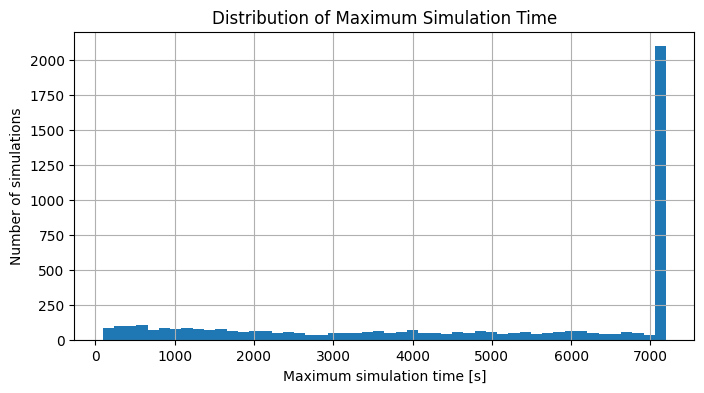

In [18]:
plt.figure(figsize=(8, 4))

plt.hist(
    metadata_clean["maximum_time"],
    bins=50
)

plt.xlabel("Maximum simulation time [s]")
plt.ylabel("Number of simulations")
plt.title("Distribution of Maximum Simulation Time")

plt.grid(True)
plt.show()

## Maximum Simulation Time Prediction

The second prediction task was to predict the **maximum physical simulation time** from the 15 static input parameters of each simulation.

Unlike `sequence_length`, which represents the number of recorded simulation states, `maximum_time` represents the actual physical time corresponding to the final recorded state. No fixed relationship between the number of states and physical time was assumed, since the simulation time intervals are not uniform.

### Input

The same 15 static simulation parameters used for sequence-length prediction were used:

- Psys
- Ffuel
- Porosity
- Dparticle
- Alpha
- Rflat
- Tbed
- Decay
- Fstruct
- Rcake
- Topcake
- Botcake
- Porcake
- Partdiacake
- Hdebris

### Target

The target variable was defined as:

`log1p(maximum_time)`

The logarithmic transformation was used to reduce the effect of the strongly skewed distribution of simulation times.

Two quantile regression models were trained:

- **P50 model:** predicts the median maximum simulation time
- **P75 model:** predicts the 75th percentile of maximum simulation time

### Results

#### P50 model

- MAE in log space: **0.280**
- RMSE in log space: **0.468**
- MAE in original scale: **961.4 s**
- P50 coverage: **52.3%**
- MdAPE: **16.0%**

#### P75 model

- MAE in log space: **0.353**
- RMSE in log space: **0.644**
- MAE in original scale: **1049.1 s**
- P75 coverage: **70.3%**
- MdAPE: **15.1%**

The P50 model is reasonably well calibrated, with 52.3% of the actual maximum simulation times falling below the predicted P50 value. The P75 model currently underestimates the desired 75% coverage, achieving approximately 70.3%.

### Dependence on Simulation Time

The prediction error was evaluated for different ranges of actual maximum simulation time.

| Actual maximum time [s] | Number of cases | MAE [s] | MdAPE |
|---|---:|---:|---:|
| 0–1000 | 53 | 788.6 | 75.3% |
| 1000–2000 | 52 | 1052.3 | 29.2% |
| 2000–3000 | 33 | 865.1 | 23.6% |
| 3000–4000 | 39 | 682.0 | 13.5% |
| 4000–5000 | 32 | 994.1 | 21.0% |
| 5000–6000 | 42 | 943.7 | 15.6% |
| 6000–6500 | 20 | 947.6 | 7.9% |
| 6500–7000 | 21 | 1363.2 | 18.5% |
| 7000–7500 | 203 | 1010.9 | 9.3% |

The model performs considerably better in relative terms for long-running simulations. The MdAPE decreases from **75.3%** for simulations below 1000 s to **9.3%** for simulations between 7000 and 7500 s.

The absolute errors remain on the order of several hundred to approximately 1000 s across most duration ranges. Therefore, the large relative errors at short simulation times are partly caused by the smaller denominator in the relative-error calculation.

### Key Observation

A large fraction of the simulations run close to the 7200 s upper simulation limit. These long-running simulations are predicted relatively well, while early-terminating simulations are considerably more difficult to predict.

This suggests that the simulation population may contain different prediction regimes:

```text
Static input parameters
        |
        v
+-------------------------+
| Simulation termination  |
| behaviour               |
+------------+------------+
             |
       +-----+-----+
       |           |
       v           v
 Long-running   Early termination
 simulations    simulations
       |           |
       v           v
 ~7200 s       variable duration

In [25]:
maximum_time_results = pd.read_csv(
    DATA_DIR/"processed/maximum_time_predictions.csv"
)

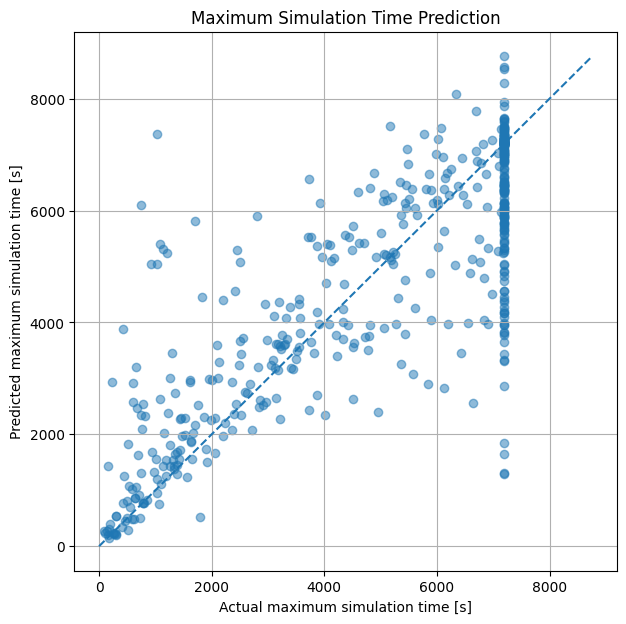

In [26]:
plt.figure(figsize=(7, 7))

plt.scatter(
    maximum_time_results["maximum_time"],
    maximum_time_results["predicted_maximum_time_p50"],
    alpha=0.5
)

max_value = max(
    maximum_time_results["maximum_time"].max(),
    maximum_time_results["predicted_maximum_time_p50"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.xlabel("Actual maximum simulation time [s]")
plt.ylabel("Predicted maximum simulation time [s]")
plt.title("Maximum Simulation Time Prediction")

plt.grid(True)
plt.show()

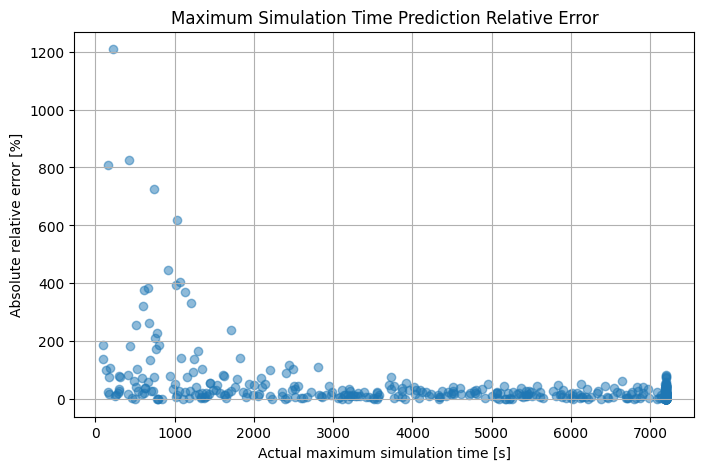

In [27]:
plt.figure(figsize=(8, 5))

plt.scatter(
    maximum_time_results["maximum_time"],
    maximum_time_results["relative_error_p50"] * 100,
    alpha=0.5
)

plt.xlabel("Actual maximum simulation time [s]")
plt.ylabel("Absolute relative error [%]")
plt.title("Maximum Simulation Time Prediction Relative Error")

plt.grid(True)
plt.show()

In [28]:
bins = [
    0,
    1000,
    2000,
    3000,
    4000,
    5000,
    6000,
    6500,
    7000,
    7500
]

maximum_time_results["time_bin"] = pd.cut(
    maximum_time_results["maximum_time"],
    bins=bins
)

grouped = maximum_time_results.groupby(
    "time_bin",
    observed=True
)

summary = grouped.apply(
    lambda x: pd.Series({
        "N": len(x),
        "MAE": np.mean(
            np.abs(
                x["predicted_maximum_time_p50"]
                - x["maximum_time"]
            )
        ),
        "MdAPE": np.median(
            np.abs(
                x["predicted_maximum_time_p50"]
                - x["maximum_time"]
            )
            / x["maximum_time"]
        ) * 100,
    })
)

summary

/tmp/ipykernel_1294147/2806790813.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = grouped.apply(


,N,MAE,MdAPE
time_bin,,,
"(0, 1000]",53.0,788.603316,75.316883
"(1000, 2000]",52.0,1052.301354,29.246584
"(2000, 3000]",33.0,865.103665,23.567551
"(3000, 4000]",39.0,681.964871,13.549110
"(4000, 5000]",32.0,994.077125,20.978146
"(5000, 6000]",42.0,943.703990,15.626138
"(6000, 6500]",20.0,947.625553,7.919773
"(6500, 7000]",21.0,1363.234065,18.549756
"(7000, 7500]",203.0,1010.889206,9.263441


In [32]:
df= pd.read_excel("/home/ikeaprash/project/data/Simulation output with conclusion of timed out cases.xlsx")
df

,Simulation No,Psys,Ffuel,Porosity,Dparticle,Alpha,Rflat,Tbed,Decay,Fstruct,Rcake,Topcake,Botcake,Porcake,Partdiacake,Hdebris,Conclusion,Quenching Time,Timed Out Conclusion
0,0,404411.0,0.82635,0.486025,0.003924,16.839,0.5230,1512.67,0.008307,1.115375,0.122930,0.715806,0.488859,0.182432,0.000844,2.192350,Quenched,2161.000,NaN
1,1,148571.0,0.86185,0.258825,0.002791,18.597,1.8034,1253.71,0.007041,0.844125,1.142793,0.853430,0.716177,0.223470,0.001861,1.336405,Melted,NaN,NaN
2,2,411275.0,0.91785,0.423075,0.003737,16.203,0.3646,1549.33,0.003242,0.550125,0.248922,1.254117,0.696887,0.103698,0.003160,1.846595,Timed Out,17430.000,Quenched
3,3,457139.0,0.97545,0.442825,0.002564,21.129,0.1818,1286.47,0.007395,0.576375,0.185108,0.592630,0.413072,0.305848,0.000449,2.250654,Quenched,2502.330,NaN
4,4,380153.0,0.93225,0.334175,0.001651,27.843,1.0550,488.53,0.003832,1.301575,0.436180,0.513966,0.466557,0.079846,0.000250,2.334949,Quenched,919.503,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4995,321653.0,0.50355,0.295925,0.003700,36.531,0.2210,469.81,0.004996,1.575275,0.427614,1.224277,0.583157,0.079857,0.000901,2.464220,Timed Out,NaN,Melted
4996,4996,206837.0,0.56525,0.458675,0.003675,33.657,0.1538,437.31,0.008199,1.752025,0.707897,1.572917,0.913720,0.292769,0.002446,2.903183,Quenched,243.543,NaN
4997,4997,173921.0,0.91145,0.449025,0.003593,27.075,0.2102,542.35,0.008426,0.292175,0.319360,1.418967,0.494375,0.426067,0.002624,2.163850,Quenched,605.330,NaN
4998,4998,260891.0,0.65795,0.400125,0.001085,36.543,0.9886,997.61,0.006168,0.311075,0.667349,0.629582,0.393319,0.115609,0.000346,1.702737,Melted,NaN,NaN


In [33]:
df["Conclusion"]

0        Quenched
1          Melted
2       Timed Out
3        Quenched
4        Quenched
          ...    
4995    Timed Out
4996     Quenched
4997     Quenched
4998       Melted
4999    Timed Out
Name: Conclusion, Length: 5000, dtype: object

In [34]:
df["Conclusion"].value_counts(dropna= False)

Conclusion
Timed Out    2056
Quenched     1981
Melted        963
Name: count, dtype: int64

In [35]:
print(df["Timed Out Conclusion"].value_counts(dropna=False))

Timed Out Conclusion
NaN          2944
Melted       1040
Timed Out     605
Quenched      411
Name: count, dtype: int64


In [36]:
print(df["Quenching Time"].describe())

count     2392.000000
mean      4161.448303
std       5285.903188
min          0.001000
25%        977.147000
50%       2194.665000
75%       5137.702500
max      34214.800000
Name: Quenching Time, dtype: float64


In [37]:
print(
    df[
        [
            "Conclusion",
            "Quenching Time",
            "Timed Out Conclusion"
        ]
    ].drop_duplicates()
)

     Conclusion  Quenching Time Timed Out Conclusion
0      Quenched        2161.000                  NaN
1        Melted             NaN                  NaN
2     Timed Out       17430.000             Quenched
3      Quenched        2502.330                  NaN
4      Quenched         919.503                  NaN
...         ...             ...                  ...
4987   Quenched        3712.930                  NaN
4991  Timed Out       10326.200             Quenched
4994   Quenched        1876.290                  NaN
4996   Quenched         243.543                  NaN
4997   Quenched         605.330                  NaN

[2362 rows x 3 columns]


In [38]:
print(
    df["Quenching Time"].isna().value_counts()
)

Quenching Time
True     2608
False    2392
Name: count, dtype: int64


In [39]:
df.columns.tolist()

['Simulation No',
 'Psys',
 'Ffuel',
 'Porosity',
 'Dparticle',
 'Alpha',
 'Rflat',
 'Tbed',
 'Decay',
 'Fstruct',
 'Rcake',
 'Topcake',
 'Botcake',
 'Porcake',
 'Partdiacake',
 'Hdebris',
 'Conclusion',
 'Quenching Time',
 'Timed Out Conclusion']

In [2]:
import pandas as pd

path = "/home/ikeaprash/project/data/processed/trajectory/trajectory_train.parquet"

train = pd.read_parquet(path)

print(train.shape)
print(train.columns.tolist())
print(train.head())

(1977800, 27)
['Simulation No', 'particle_id', 'Psys', 'Ffuel', 'Porosity', 'Dparticle', 'Alpha', 'Rflat', 'Tbed', 'Decay', 'Fstruct', 'Rcake', 'Topcake', 'Botcake', 'Porcake', 'Partdiacake', 'Hdebris', 'x', 'y', 'z', 'time', 't_norm', 'log1p_t_norm', 'sqrt_t_norm', 't_norm_squared', 'log1p_maximum_time', 'temperature']
   Simulation No  particle_id      Psys    Ffuel  Porosity  Dparticle   Alpha  \
0              0          555  404411.0  0.82635  0.486025   0.003924  16.839   
1              0          130  404411.0  0.82635  0.486025   0.003924  16.839   
2              0          740  404411.0  0.82635  0.486025   0.003924  16.839   
3              0          580  404411.0  0.82635  0.486025   0.003924  16.839   
4              0           91  404411.0  0.82635  0.486025   0.003924  16.839   

   Rflat     Tbed     Decay  ...       x    y        z      time    t_norm  \
0  0.523  1512.67  0.008307  ...  1.8520  0.0  1.12700  155.8680  0.072176   
1  0.523  1512.67  0.008307  ...  3

In [1]:
import pandas as pd

train = pd.read_parquet(
    "/home/ikeaprash/project/data/processed/trajectory/trajectory_train.parquet"
)

print(train.columns.tolist())
print(train.shape)

['Simulation No', 'Psys', 'Ffuel', 'Porosity', 'Dparticle', 'Alpha', 'Rflat', 'Tbed', 'Decay', 'Fstruct', 'Rcake', 'Topcake', 'Botcake', 'Porcake', 'Partdiacake', 'Hdebris', 't_norm', 'log1p_t_norm', 'sqrt_t_norm', 't_norm_squared', 'log1p_maximum_time', 'mg', 'ml', 'mp', 'eg', 'el', 'ep', 'fgin', 'fgout', 'flin', 'flout', 'qgin', 'qgout', 'qlin', 'qlout', 'qpin', 'qpout', 'qsi', 'qgi', 'qli', 'qsg', 'qsl', 'pow']
(16001182, 43)


### training model for eg(t)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

pred_path = (
    "/home/ikeaprash/project/data/processed/"
    "predictions/trajectory_eg_predictions_test.parquet"
)

pred = pd.read_parquet(pred_path)

print(pred.head())
print("Test simulations:", pred["Simulation No"].nunique())

   Simulation No     time        t_norm           eg  predicted_eg
0              2  0.00100  1.389086e-07   60012588.0  4.214309e+08
1              2  1.00226  1.392225e-04  565983490.0  4.214309e+08
2              2  2.02869  2.818024e-04  411428040.0  4.214309e+08
3              2  3.19419  4.437004e-04  413216990.0  4.214309e+08
4              2  4.29981  5.972804e-04  413843060.0  4.214309e+08
Test simulations: 495


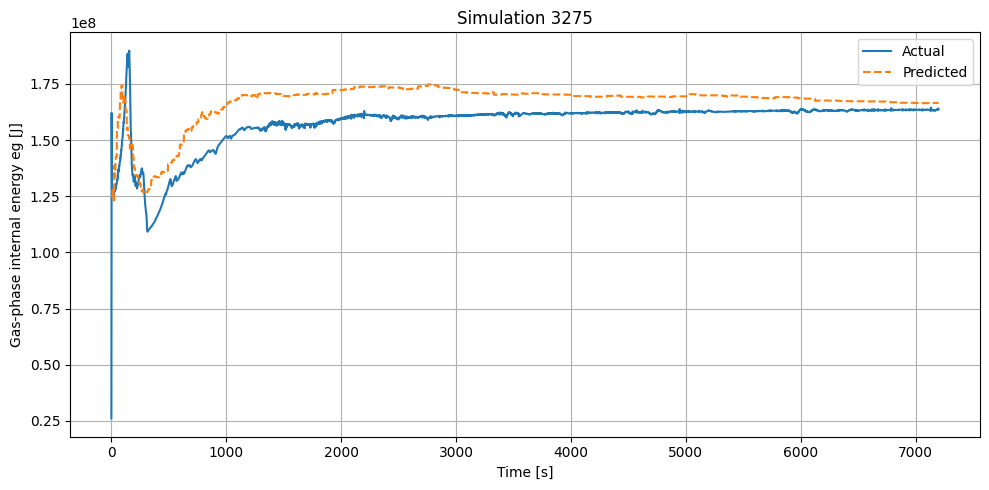

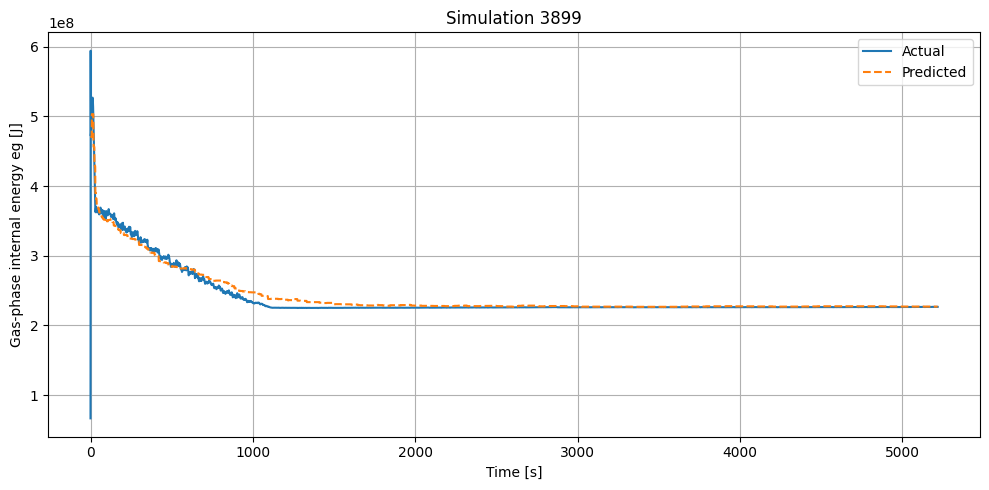

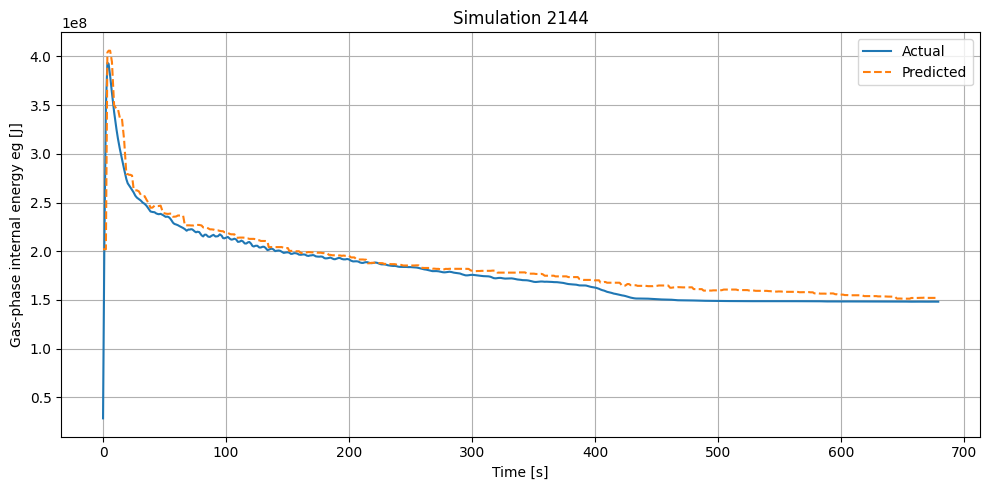

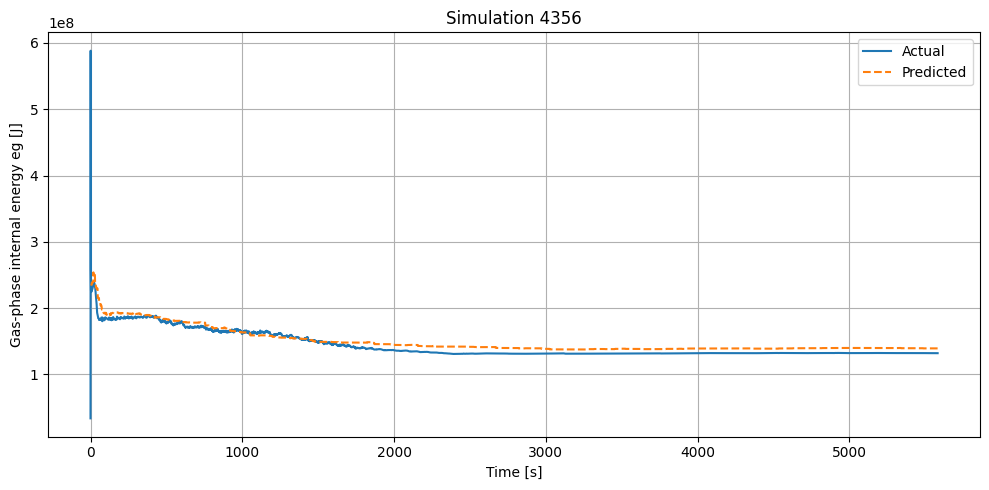

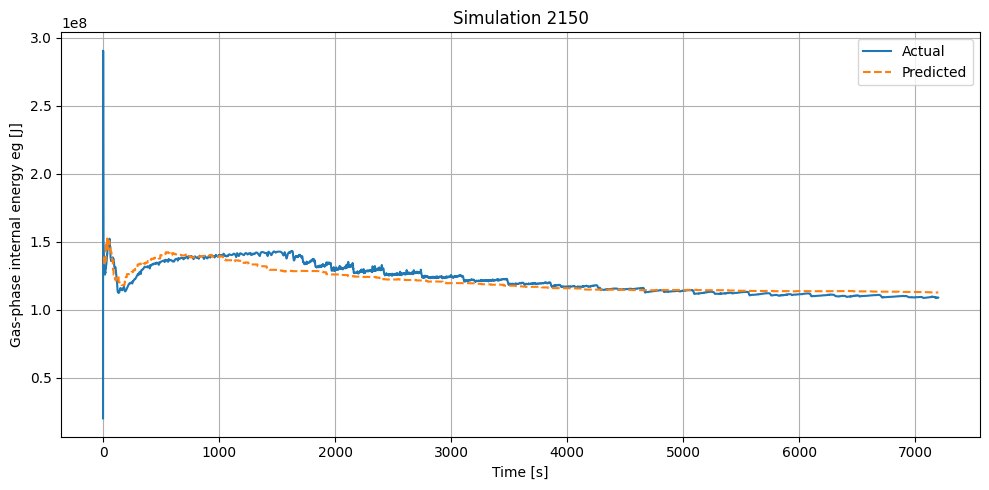

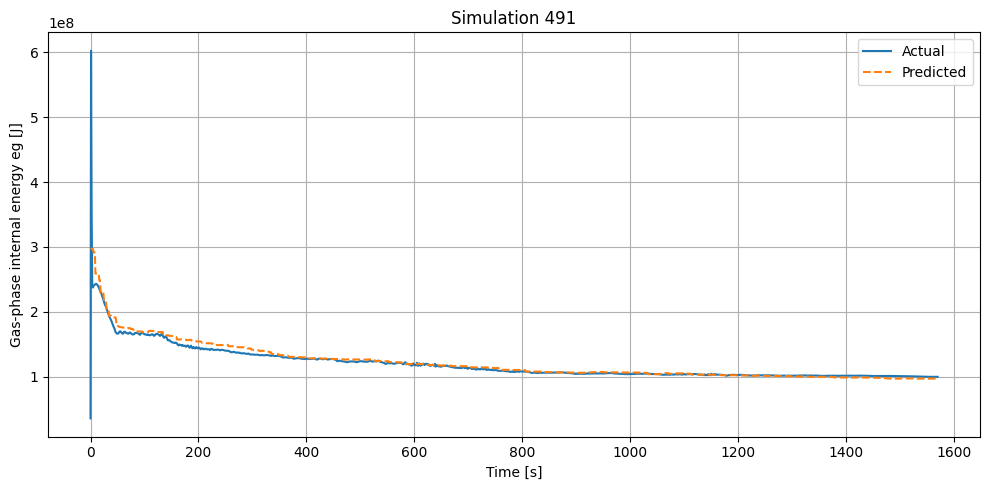

In [3]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

sim_ids = pred["Simulation No"].unique()

selected = rng.choice(
    sim_ids,
    size=6,
    replace=False
)

for sim_id in selected:

    data = pred[
        pred["Simulation No"] == sim_id
    ].sort_values("time")

    plt.figure(figsize=(10, 5))

    plt.plot(
        data["time"],
        data["eg"],
        label="Actual"
    )

    plt.plot(
        data["time"],
        data["predicted_eg"],
        "--",
        label="Predicted"
    )

    plt.xlabel("Time [s]")
    plt.ylabel("Gas-phase internal energy eg [J]")
    plt.title(
        f"Simulation {sim_id}"
    )

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [6]:
import pandas as pd

conclusion_path = (
    "/home/ikeaprash/project/data/Simulation output with conclusion of timed out cases.xlsx"
)

conclusion = pd.read_excel(conclusion_path)

print(conclusion.shape)
print(conclusion.columns.tolist())

print("\nConclusion:")
print(conclusion["Conclusion"].value_counts(dropna=False))

print("\nTimed Out Conclusion:")
print(
    conclusion["Timed Out Conclusion"]
    .value_counts(dropna=False)
)

(5000, 19)
['Simulation No', 'Psys', 'Ffuel', 'Porosity', 'Dparticle', 'Alpha', 'Rflat', 'Tbed', 'Decay', 'Fstruct', 'Rcake', 'Topcake', 'Botcake', 'Porcake', 'Partdiacake', 'Hdebris', 'Conclusion', 'Quenching Time', 'Timed Out Conclusion']

Conclusion:
Conclusion
Timed Out    2056
Quenched     1981
Melted        963
Name: count, dtype: int64

Timed Out Conclusion:
Timed Out Conclusion
NaN          2944
Melted       1040
Timed Out     605
Quenched      411
Name: count, dtype: int64


In [7]:
print(
    conclusion[
        [
            "Simulation No",
            "Conclusion",
            "Quenching Time",
            "Timed Out Conclusion"
        ]
    ].head(20)
)

    Simulation No Conclusion  Quenching Time Timed Out Conclusion
0               0   Quenched        2161.000                  NaN
1               1     Melted             NaN                  NaN
2               2  Timed Out       17430.000             Quenched
3               3   Quenched        2502.330                  NaN
4               4   Quenched         919.503                  NaN
5               5   Quenched        1012.810                  NaN
6               6   Quenched         466.394                  NaN
7               7   Quenched        2207.080                  NaN
8               8     Melted             NaN                  NaN
9               9   Quenched        2549.020                  NaN
10             10   Quenched        1071.090                  NaN
11             11  Timed Out       14976.200             Quenched
12             12  Timed Out             NaN            Timed Out
13             13  Timed Out             NaN               Melted
14        

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Load eg predictions
# ============================================================

pred_path = (
    "/home/ikeaprash/project/data/processed/"
    "predictions/trajectory_eg_predictions_test.parquet"
)

pred = pd.read_parquet(pred_path)

print("Prediction data:", pred.shape)


# ============================================================
# Load simulation conclusions
# ============================================================

conclusion_path = (
    "/home/ikeaprash/project/data/Simulation output with conclusion of timed out cases.xlsx"
)

conclusion = pd.read_excel(conclusion_path)

print("Conclusion data:", conclusion.shape)

print("\nColumns:")
print(conclusion.columns.tolist())


# ============================================================
# Keep only classification information
# ============================================================

case_info = conclusion[
    [
        "Simulation No",
        "Conclusion",
        "Quenching Time",
        "Timed Out Conclusion",
    ]
].copy()


# ============================================================
# Create final physical case
# ============================================================

def get_final_case(row):

    if row["Conclusion"] == "Timed Out":
        return row["Timed Out Conclusion"]

    return row["Conclusion"]


case_info["final_case"] = case_info.apply(
    get_final_case,
    axis=1
)


print("\nFinal case distribution:")
print(
    case_info["final_case"]
    .value_counts(dropna=False)
)


# ============================================================
# Merge with predictions
# ============================================================

pred = pred.merge(
    case_info[
        [
            "Simulation No",
            "Conclusion",
            "Quenching Time",
            "Timed Out Conclusion",
            "final_case",
        ]
    ],
    on="Simulation No",
    how="left"
)


print("\nAfter merge:", pred.shape)

print("\nMissing case information:")
print(
    pred["final_case"].isna().sum()
)


# ============================================================
# Check test simulations
# ============================================================

sim_case = (
    pred[
        [
            "Simulation No",
            "final_case"
        ]
    ]
    .drop_duplicates()
)

print("\nTest simulations by case:")
print(
    sim_case["final_case"]
    .value_counts(dropna=False)
)

Prediction data: (2025177, 5)
Conclusion data: (5000, 19)

Columns:
['Simulation No', 'Psys', 'Ffuel', 'Porosity', 'Dparticle', 'Alpha', 'Rflat', 'Tbed', 'Decay', 'Fstruct', 'Rcake', 'Topcake', 'Botcake', 'Porcake', 'Partdiacake', 'Hdebris', 'Conclusion', 'Quenching Time', 'Timed Out Conclusion']

Final case distribution:
final_case
Quenched     2392
Melted       2003
Timed Out     605
Name: count, dtype: int64

After merge: (2025177, 9)

Missing case information:
0

Test simulations by case:
final_case
Quenched     231
Melted       213
Timed Out     51
Name: count, dtype: int64



Selected simulations:
Quenched: Simulation 326
Melted: Simulation 4099
Timed Out: Simulation 2824


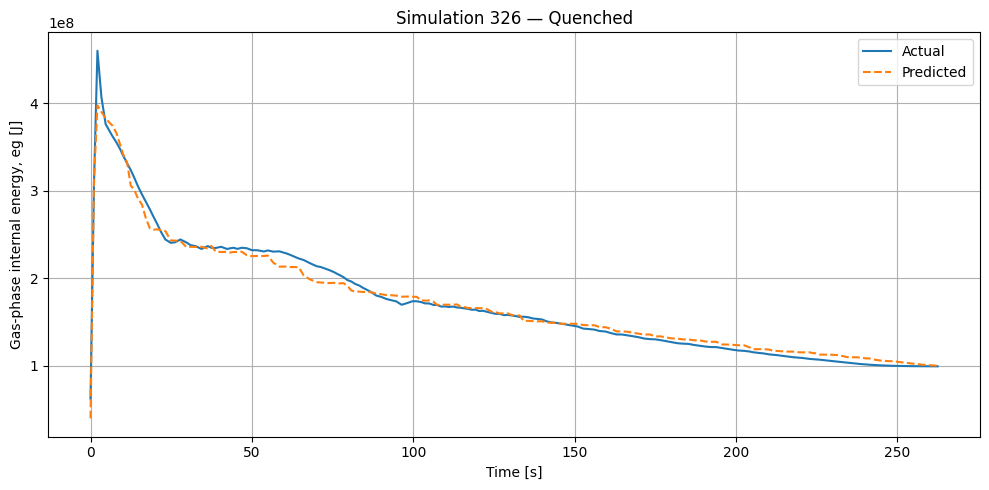

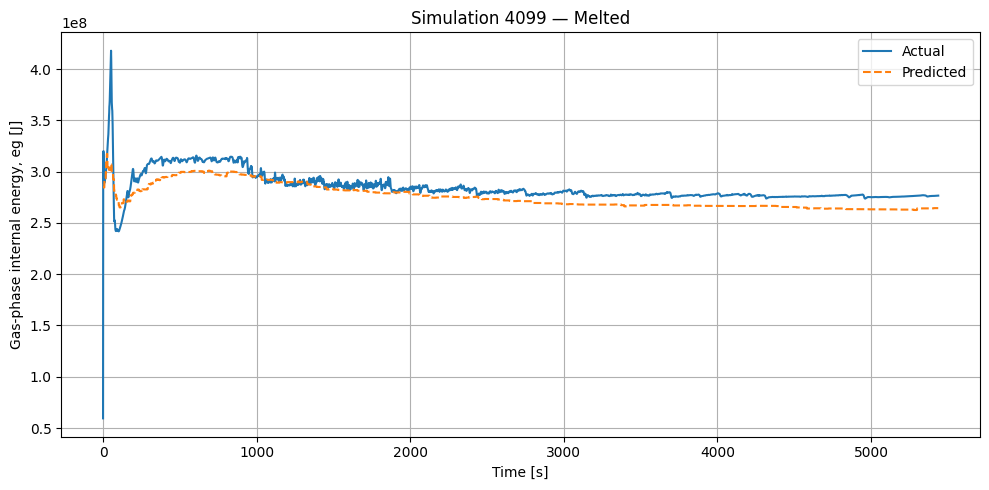

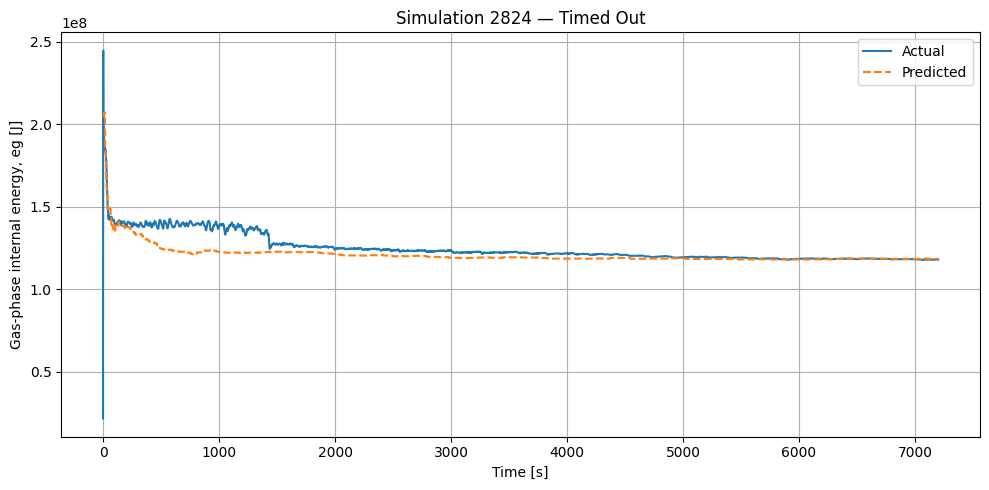

In [10]:
# ============================================================
# Select representative simulations
# ============================================================

rng = np.random.default_rng(42)

selected = {}

for case in ["Quenched", "Melted", "Timed Out"]:

    ids = sim_case.loc[
        sim_case["final_case"] == case,
        "Simulation No"
    ].to_numpy()

    if len(ids) == 0:
        print(f"No test simulations found for {case}")
        continue

    selected[case] = rng.choice(ids)


print("\nSelected simulations:")

for case, sim_id in selected.items():
    print(
        f"{case}: Simulation {sim_id}"
    )


# ============================================================
# Plot
# ============================================================

for case, sim_id in selected.items():

    data = (
        pred[
            pred["Simulation No"] == sim_id
        ]
        .sort_values("time")
    )

    plt.figure(figsize=(10, 5))

    plt.plot(
        data["time"],
        data["eg"],
        label="Actual"
    )

    plt.plot(
        data["time"],
        data["predicted_eg"],
        "--",
        label="Predicted"
    )

    plt.xlabel("Time [s]")
    plt.ylabel("Gas-phase internal energy, eg [J]")

    plt.title(
        f"Simulation {sim_id} — {case}"
    )

    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plt.show()

In [11]:
import pandas as pd
import numpy as np

path = (
    "/home/ikeaprash/project/data/processed/"
    "trajectory/trajectory_test.parquet"
)

df = pd.read_parquet(path)

targets = [
    "mg", "ml", "mp",
    "eg", "el", "ep",
    "fgin", "fgout",
    "flin", "flout",
    "qgin", "qgout",
    "qlin", "qlout",
    "qpin", "qpout",
    "qsi", "qgi", "qli",
    "qsg", "qsl", "pow"
]

# variation within each simulation
stats = []

for target in targets:

    grouped = df.groupby("Simulation No")[target]

    sim_std = grouped.std()
    sim_range = grouped.max() - grouped.min()

    stats.append({
        "variable": target,
        "median_std": sim_std.median(),
        "max_std": sim_std.max(),
        "median_range": sim_range.median(),
        "max_range": sim_range.max(),
        "constant_fraction": np.mean(
            sim_range < 1e-10
        )
    })

stats = pd.DataFrame(stats)

print(
    stats.sort_values(
        "constant_fraction",
        ascending=False
    ).to_string(index=False)
)

variable   median_std      max_std  median_range    max_range  constant_fraction
    qgin 0.000000e+00 0.000000e+00  0.000000e+00 0.000000e+00           1.000000
     qgi 0.000000e+00 0.000000e+00  0.000000e+00 0.000000e+00           1.000000
    qpin 0.000000e+00 0.000000e+00  0.000000e+00 0.000000e+00           1.000000
   qpout 0.000000e+00 0.000000e+00  0.000000e+00 0.000000e+00           1.000000
    fgin 0.000000e+00 0.000000e+00  0.000000e+00 0.000000e+00           1.000000
      mp 0.000000e+00 4.116890e-01  0.000000e+00 2.083000e+01           0.975758
     pow 0.000000e+00 6.828543e+01  0.000000e+00 3.455000e+03           0.973737
     qsl 0.000000e+00 6.064805e+05  0.000000e+00 2.936986e+07           0.517172
      ep 1.128160e+10 5.496068e+10  4.683559e+10 2.172249e+11           0.000000
      ml 7.926848e+03 2.572146e+04  8.482801e+04 1.203806e+05           0.000000
      mg 6.345319e+00 4.253941e+01  1.056428e+02 2.894727e+02           0.000000
      el 4.439752e+09 1.5888

In [12]:
mp_stats = (
    df.groupby("Simulation No")["mp"]
    .agg([
        "first",
        "last",
        "min",
        "max",
        "std"
    ])
)

print(mp_stats.head(20))

print("\nFraction effectively constant:")

print(
    np.mean(
        (mp_stats["max"] - mp_stats["min"])
        < 1e-6
    )
)

                   first       last        min        max  std
Simulation No                                                 
2              194710.72  194710.72  194710.72  194710.72  0.0
14             143498.33  143498.33  143498.33  143498.33  0.0
15             143733.78  143733.78  143733.78  143733.78  0.0
16             304031.68  304031.68  304031.68  304031.68  0.0
35             291073.63  291073.63  291073.63  291073.63  0.0
37             192390.37  192390.37  192390.37  192390.37  0.0
46             253367.52  253367.52  253367.52  253367.52  0.0
47             123288.70  123288.70  123288.70  123288.70  0.0
51             266399.50  266399.50  266399.50  266399.50  0.0
56             181733.28  181733.28  181733.28  181733.28  0.0
65             278003.52  278003.52  278003.52  278003.52  0.0
80             175715.46  175715.46  175715.46  175715.46  0.0
81             102097.60  102097.60  102097.60  102097.60  0.0
95             182401.38  182401.38  182401.38  182401.

In [13]:
initial = (
    df.sort_values("time")
      .groupby("Simulation No")
      .first()
)

parameters = [
    "Psys",
    "Ffuel",
    "Porosity",
    "Dparticle",
    "Alpha",
    "Rflat",
    "Tbed",
    "Decay",
    "Fstruct",
    "Rcake",
    "Topcake",
    "Botcake",
    "Porcake",
    "Partdiacake",
    "Hdebris"
]

print(
    initial[
        parameters + ["mp"]
    ].head()
)

                   Psys    Ffuel  Porosity  Dparticle   Alpha   Rflat  \
Simulation No                                                           
2              411275.0  0.91785  0.423075   0.003737  16.203  0.3646   
14             279377.0  0.54155  0.441925   0.002124  25.377  0.8266   
15             420401.0  0.61855  0.335975   0.002192  33.399  1.0038   
16             445205.0  0.81565  0.405025   0.002690  39.951  1.0130   
35             483425.0  0.86985  0.406925   0.002632  36.093  0.9274   

                  Tbed     Decay   Fstruct     Rcake   Topcake   Botcake  \
Simulation No                                                              
2              1549.33  0.003242  0.550125  0.248922  1.254117  0.696887   
14             1376.69  0.008433  0.943175  0.550577  0.547622  0.337327   
15              759.71  0.005763  0.704475  0.322900  0.800399  0.429528   
16              530.13  0.008356  1.744675  0.285599  0.650574  0.479579   
35             1666.07  0.007152

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE = "/home/ikeaprash/project/data/processed"

test_path = (
    f"{BASE}/trajectory/trajectory_test.parquet"
)

test = pd.read_parquet(test_path)

print(test.shape)

(2025177, 44)


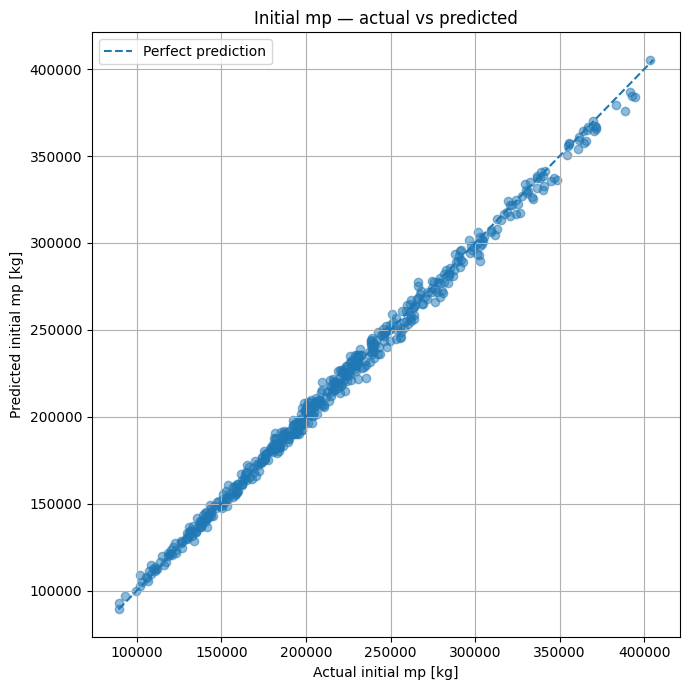

Initial mp MAE: 3235.0221361318936
Initial mp RMSE: 4139.991000510799
Initial mp bias: -57.87570737389118


In [17]:
target = "mp"

pred_path = (
    f"{BASE}/predictions/"
    f"trajectory_{target}_predictions_test.parquet"
)

pred = pd.read_parquet(pred_path)

# Sort so the first row is the earliest timestep
pred = pred.sort_values(
    ["Simulation No", "time"]
)

# One initial point per simulation
initial = (
    pred.groupby("Simulation No")
        .first()
        .reset_index()
)

actual = initial[target]
predicted = initial[f"predicted_{target}"]

plt.figure(figsize=(7, 7))

plt.scatter(
    actual,
    predicted,
    alpha=0.5
)

# Perfect prediction line
lo = min(actual.min(), predicted.min())
hi = max(actual.max(), predicted.max())

plt.plot(
    [lo, hi],
    [lo, hi],
    "--",
    label="Perfect prediction"
)

plt.xlabel("Actual initial mp [kg]")
plt.ylabel("Predicted initial mp [kg]")
plt.title("Initial mp — actual vs predicted")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

print(
    "Initial mp MAE:",
    np.mean(np.abs(actual - predicted))
)

print(
    "Initial mp RMSE:",
    np.sqrt(
        np.mean((actual - predicted) ** 2)
    )
)

print(
    "Initial mp bias:",
    np.mean(predicted - actual)
)

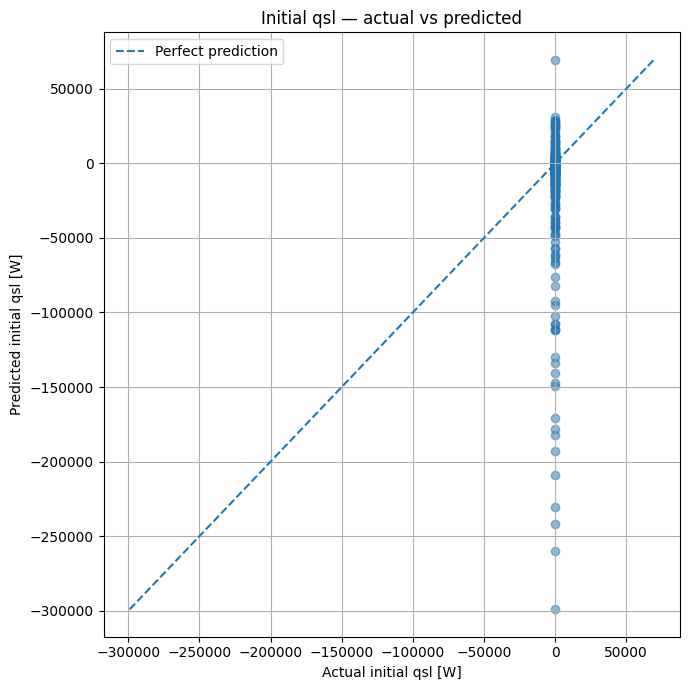

Initial qsl MAE: 14647.813310640746
Initial qsl RMSE: 38577.89669833389
Initial qsl bias: -10254.264892083109


In [19]:
target = "qsl"

pred_path = (
    f"{BASE}/predictions/"
    f"trajectory_{target}_predictions_test.parquet"
)

pred = pd.read_parquet(pred_path)

pred = pred.sort_values(
    ["Simulation No", "time"]
)

initial = (
    pred.groupby("Simulation No")
        .first()
        .reset_index()
)

actual = initial[target]
predicted = initial[f"predicted_{target}"]

plt.figure(figsize=(7, 7))

plt.scatter(
    actual,
    predicted,
    alpha=0.5
)

lo = min(actual.min(), predicted.min())
hi = max(actual.max(), predicted.max())

plt.plot(
    [lo, hi],
    [lo, hi],
    "--",
    label="Perfect prediction"
)

plt.xlabel("Actual initial qsl [W]")
plt.ylabel("Predicted initial qsl [W]")
plt.title("Initial qsl — actual vs predicted")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

print(
    "Initial qsl MAE:",
    np.mean(np.abs(actual - predicted))
)

print(
    "Initial qsl RMSE:",
    np.sqrt(
        np.mean((actual - predicted) ** 2)
    )
)

print(
    "Initial qsl bias:",
    np.mean(predicted - actual)
)

In [20]:
initial_state = (
    test.sort_values(
        ["Simulation No", "time"]
    )
    .groupby("Simulation No")
    .first()
    .reset_index()
)

parameters = [
    "Psys",
    "Ffuel",
    "Porosity",
    "Dparticle",
    "Alpha",
    "Rflat",
    "Tbed",
    "Decay",
    "Fstruct",
    "Rcake",
    "Topcake",
    "Botcake",
    "Porcake",
    "Partdiacake",
    "Hdebris",
]

print(
    initial_state[
        ["Simulation No"] + parameters + ["mp", "qsl"]
    ].head()
)

   Simulation No      Psys    Ffuel  Porosity  Dparticle   Alpha   Rflat  \
0              2  411275.0  0.91785  0.423075   0.003737  16.203  0.3646   
1             14  279377.0  0.54155  0.441925   0.002124  25.377  0.8266   
2             15  420401.0  0.61855  0.335975   0.002192  33.399  1.0038   
3             16  445205.0  0.81565  0.405025   0.002690  39.951  1.0130   
4             35  483425.0  0.86985  0.406925   0.002632  36.093  0.9274   

      Tbed     Decay   Fstruct     Rcake   Topcake   Botcake   Porcake  \
0  1549.33  0.003242  0.550125  0.248922  1.254117  0.696887  0.103698   
1  1376.69  0.008433  0.943175  0.550577  0.547622  0.337327  0.331654   
2   759.71  0.005763  0.704475  0.322900  0.800399  0.429528  0.230989   
3   530.13  0.008356  1.744675  0.285599  0.650574  0.479579  0.350355   
4  1666.07  0.007152  1.459775  0.164047  0.599126  0.378537  0.197372   

   Partdiacake   Hdebris         mp  qsl  
0     0.003160  1.846595  194710.72  0.0  
1     0.0009

### inspect qsl activation

In [21]:
import pandas as pd
import numpy as np

path = (
    "/home/ikeaprash/project/data/processed/"
    "trajectory/trajectory_train.parquet"
)

df = pd.read_parquet(path)

# ------------------------------------------------------------
# Initial qsl
# ------------------------------------------------------------

initial = (
    df.sort_values(["Simulation No", "time"])
      .groupby("Simulation No")
      .first()
)

qsl_initial = initial["qsl"]

print("Initial qsl statistics")
print(qsl_initial.describe())

print("\nInitial qsl == 0:")
print(
    np.mean(
        np.isclose(qsl_initial, 0)
    )
)

print("\nInitial qsl > 0:")
print(
    np.mean(qsl_initial > 0)
)

print("\nInitial qsl < 0:")
print(
    np.mean(qsl_initial < 0)
)

Initial qsl statistics
count    3956.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: qsl, dtype: float64

Initial qsl == 0:
1.0

Initial qsl > 0:
0.0

Initial qsl < 0:
0.0


In [22]:
# ------------------------------------------------------------
# Per-simulation qsl behavior
# ------------------------------------------------------------

qsl_stats = (
    df.groupby("Simulation No")["qsl"]
      .agg(
          first="first",
          last="last",
          minimum="min",
          maximum="max",
          mean="mean",
          std="std",
      )
)

qsl_stats["nonzero_fraction"] = (
    df.assign(
        qsl_nonzero=np.abs(df["qsl"]) > 1e-8
    )
    .groupby("Simulation No")["qsl_nonzero"]
    .mean()
)

print(
    qsl_stats.describe()
)

        first          last       minimum       maximum          mean  \
count  3956.0  3.956000e+03  3.956000e+03  3.956000e+03  3.956000e+03   
mean      0.0 -2.562033e+04 -1.077740e+06  2.698094e+04 -2.645745e+04   
std       0.0  1.153808e+05  2.980415e+06  1.901200e+05  1.173529e+05   
min       0.0 -1.815576e+06 -5.441194e+07  0.000000e+00 -1.799568e+06   
25%       0.0  0.000000e+00 -7.559697e+05  0.000000e+00 -4.135465e+02   
50%       0.0  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
75%       0.0  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
max       0.0  0.000000e+00  0.000000e+00  5.899790e+06  3.529333e+02   

                 std  nonzero_fraction  
count    3956.000000       3956.000000  
mean    25177.549760          0.101175  
std     71779.324254          0.291431  
min         0.000000          0.000000  
25%         0.000000          0.000000  
50%         0.000000          0.000000  
75%     15213.641473          0.001544  
max    834096.

In [23]:
print(
    qsl_stats[
        ["first", "last", "minimum", "maximum", "nonzero_fraction"]
    ]
    .head(30)
)

               first        last       minimum      maximum  nonzero_fraction
Simulation No                                                                
0                0.0       0.000  0.000000e+00        0.000          0.000000
3                0.0       0.000 -3.702981e+06        0.000          0.000483
4                0.0       0.000  0.000000e+00        0.000          0.000000
6                0.0       0.000  0.000000e+00        0.000          0.000000
7                0.0       0.000  0.000000e+00        0.000          0.000000
8                0.0       0.000  0.000000e+00        0.000          0.000000
9                0.0       0.000  0.000000e+00        0.000          0.000000
10               0.0       0.000 -2.668588e+06        0.000          0.001111
12               0.0       0.000  0.000000e+00        0.000          0.000000
13               0.0  -57982.117 -1.345593e+06    31887.883          0.917779
17               0.0       0.000  0.000000e+00        0.000     

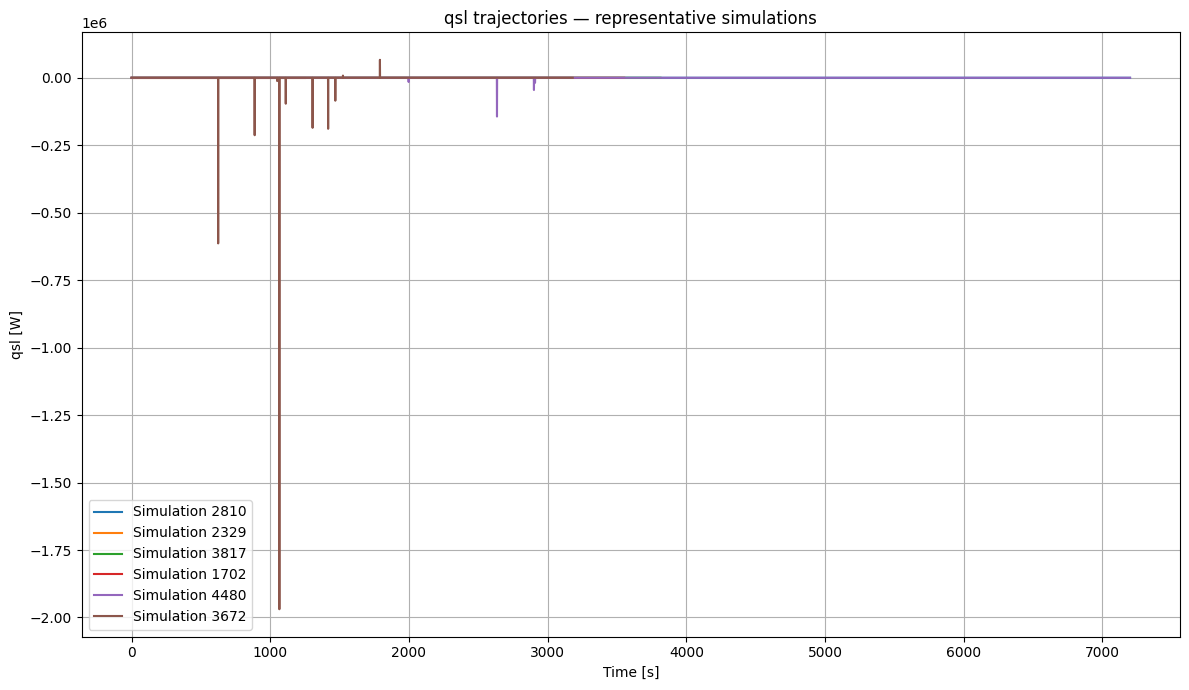

In [24]:
import matplotlib.pyplot as plt

# Pick 6 simulations
sim_ids = (
    qsl_stats
    .sort_values("nonzero_fraction")
    .index
)

selected = [
    sim_ids[0],
    sim_ids[len(sim_ids)//6],
    sim_ids[2*len(sim_ids)//6],
    sim_ids[3*len(sim_ids)//6],
    sim_ids[4*len(sim_ids)//6],
    sim_ids[5*len(sim_ids)//6],
]

plt.figure(figsize=(12, 7))

for sim_id in selected:

    sim = (
        df[df["Simulation No"] == sim_id]
        .sort_values("time")
    )

    plt.plot(
        sim["time"],
        sim["qsl"],
        label=f"Simulation {sim_id}"
    )

plt.xlabel("Time [s]")
plt.ylabel("qsl [W]")
plt.title("qsl trajectories — representative simulations")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

determine whether qsl activation is predictable from the simulation parameters


In [25]:
qsl_sim = (
    df.groupby("Simulation No")
      .agg(
          qsl_nonzero_fraction=(
              "qsl",
              lambda x: np.mean(np.abs(x) > 1e-8)
          ),
          qsl_min=("qsl", "min"),
          qsl_max=("qsl", "max"),
      )
)

qsl_sim["qsl_active"] = (
    qsl_sim["qsl_nonzero_fraction"] > 0
)

print(qsl_sim["qsl_active"].value_counts())

print(
    qsl_sim["qsl_nonzero_fraction"]
    .describe()
)

qsl_active
False    2103
True     1853
Name: count, dtype: int64
count    3956.000000
mean        0.101175
std         0.291431
min         0.000000
25%         0.000000
50%         0.000000
75%         0.001544
max         0.998899
Name: qsl_nonzero_fraction, dtype: float64


In [26]:
initial = (
    df.sort_values(["Simulation No", "time"])
      .groupby("Simulation No")
      .first()
)

parameters = [
    "Psys",
    "Ffuel",
    "Porosity",
    "Dparticle",
    "Alpha",
    "Rflat",
    "Tbed",
    "Decay",
    "Fstruct",
    "Rcake",
    "Topcake",
    "Botcake",
    "Porcake",
    "Partdiacake",
    "Hdebris",
]

qsl_sim = qsl_sim.join(
    initial[parameters]
)

print(
    qsl_sim.groupby("qsl_active")[parameters]
           .mean()
           .T
)

qsl_active           False          True 
Psys         320611.071327  286240.705343
Ffuel             0.744641       0.751843
Porosity          0.360613       0.390602
Dparticle         0.003339       0.002616
Alpha            29.728358      30.447589
Rflat             0.988495       1.017013
Tbed            966.662458    1161.693152
Decay             0.007084       0.005795
Fstruct           0.998158       1.274687
Rcake             0.502011       0.609965
Topcake           0.898132       0.995168
Botcake           0.555726       0.603599
Porcake           0.216820       0.233252
Partdiacake       0.001826       0.001417
Hdebris           2.001025       2.242140


In [27]:
def first_nonzero_time(group):

    active = (
        np.abs(group["qsl"]) > 1e-8
    )

    if not active.any():
        return np.nan

    return group.loc[
        active,
        "time"
    ].iloc[0]


activation_time = (
    df.sort_values(
        ["Simulation No", "time"]
    )
    .groupby("Simulation No")
    .apply(
        first_nonzero_time
    )
)

print(
    activation_time.describe()
)

count    1853.000000
mean     1045.630507
std      1163.260117
min         7.053350
25%       242.746630
50%       695.944300
75%      1391.182900
max      6899.131800
dtype: float64


/tmp/ipykernel_2146915/3255145592.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [28]:
print(
    activation_time.notna().value_counts()
)

False    2103
True     1853
Name: count, dtype: int64


In [29]:
qsl_values = df["qsl"].abs()

print(
    qsl_values[qsl_values > 0]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

count    1.649523e+06
mean     2.225300e+05
std      3.090636e+05
min      3.083800e-01
1%       2.033555e+04
5%       3.318635e+04
10%      3.987344e+04
25%      6.871513e+04
50%      1.287952e+05
75%      2.641309e+05
90%      5.086127e+05
95%      7.045343e+05
99%      1.380583e+06
max      5.441194e+07
Name: qsl, dtype: float64


In [30]:
print(
    "Values between 0 and 1 W:",
    ((qsl_values > 0) & (qsl_values < 1)).sum()
)

print(
    "Values between 1 and 100 W:",
    ((qsl_values >= 1) & (qsl_values < 100)).sum()
)

print(
    "Values between 100 and 1e4 W:",
    ((qsl_values >= 100) & (qsl_values < 1e4)).sum()
)

print(
    "Values above 1e4 W:",
    (qsl_values >= 1e4).sum()
)


Values between 0 and 1 W: 3
Values between 1 and 100 W: 99
Values between 100 and 1e4 W: 4208
Values above 1e4 W: 1645213


In [31]:
threshold = 1e4

qsl_activity = (
    df.groupby("Simulation No")["qsl"]
      .apply(
          lambda x: (x.abs() > threshold).any()
      )
)

print(
    qsl_activity.value_counts()
)

print(
    "\nActive fraction:",
    qsl_activity.mean()
)

qsl
False    2151
True     1805
Name: count, dtype: int64

Active fraction: 0.4562689585439838


In [32]:
qsl_fraction = (
    df.groupby("Simulation No")["qsl"]
      .apply(
          lambda x: (x.abs() > threshold).mean()
      )
)

print(
    qsl_fraction.describe()
)

count    3956.000000
mean        0.100934
std         0.291325
min         0.000000
25%         0.000000
50%         0.000000
75%         0.001236
max         0.998899
Name: qsl, dtype: float64


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

DATA = Path("/home/ikeaprash/project/data/processed/trajectory")

train = pd.read_parquet(
    DATA / "trajectory_train.parquet"
)

print(train.shape)

(16001182, 44)


In [34]:
QSL_THRESHOLD = 10_000

train["qsl_active"] = (
    train["qsl"].abs() > QSL_THRESHOLD
)

print(
    train["qsl_active"]
    .value_counts()
)

print(
    "Active fraction:",
    train["qsl_active"].mean()
)

qsl_active
False    14355969
True      1645213
Name: count, dtype: int64
Active fraction: 0.10281821680423359


In [35]:
def analyze_qsl_simulation(g):

    g = g.sort_values("time").reset_index(drop=True)

    active = (
        g["qsl"].abs() > QSL_THRESHOLD
    ).to_numpy()

    times = g["time"].to_numpy()
    qsl = g["qsl"].to_numpy()

    active_indices = np.where(active)[0]

    if len(active_indices) == 0:

        return pd.Series({
            "qsl_active": False,
            "first_active_time": np.nan,
            "last_active_time": np.nan,
            "active_duration": 0.0,
            "active_fraction": 0.0,
            "n_active_points": 0,
            "n_active_regions": 0,
            "n_transitions": 0,
            "max_abs_qsl": 0.0,
            "min_qsl": qsl.min(),
            "max_qsl": qsl.max(),
            "final_qsl": qsl[-1],
        })

    # --------------------------------------------------------
    # Find starts of active regions
    # --------------------------------------------------------

    starts = (
        active
        & ~np.r_[False, active[:-1]]
    )

    ends = (
        active
        & ~np.r_[active[1:], False]
    )

    start_indices = np.where(starts)[0]
    end_indices = np.where(ends)[0]

    # --------------------------------------------------------
    # Number of transitions
    # --------------------------------------------------------

    transitions = np.sum(
        active[1:] != active[:-1]
    )

    # --------------------------------------------------------
    # Active duration
    # --------------------------------------------------------

    active_time = 0.0

    for start, end in zip(
        start_indices,
        end_indices,
    ):
        active_time += (
            times[end] - times[start]
        )

    return pd.Series({

        "qsl_active": True,

        "first_active_time":
            times[active_indices[0]],

        "last_active_time":
            times[active_indices[-1]],

        "active_duration":
            active_time,

        "active_fraction":
            active.mean(),

        "n_active_points":
            len(active_indices),

        "n_active_regions":
            len(start_indices),

        "n_transitions":
            transitions,

        "max_abs_qsl":
            np.max(np.abs(qsl)),

        "min_qsl":
            qsl.min(),

        "max_qsl":
            qsl.max(),

        "final_qsl":
            qsl[-1],
    })


qsl_sim = (
    train
    .groupby("Simulation No")
    .apply(analyze_qsl_simulation)
    .reset_index()
)

qsl_sim.head()

/tmp/ipykernel_2146915/79109633.py:112: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(analyze_qsl_simulation)


,Simulation No,qsl_active,first_active_time,last_active_time,active_duration,active_fraction,n_active_points,n_active_regions,n_transitions,max_abs_qsl,min_qsl,max_qsl,final_qsl
0,0,False,NaN,NaN,0.0,0.000000,0,0,0,0.0,0.0,0.0,0.0
1,3,True,553.49426,553.49426,0.0,0.000483,1,1,2,3702980.8,-3702980.8,0.0,0.0
2,4,False,NaN,NaN,0.0,0.000000,0,0,0,0.0,0.0,0.0,0.0
3,6,False,NaN,NaN,0.0,0.000000,0,0,0,0.0,0.0,0.0,0.0
4,7,False,NaN,NaN,0.0,0.000000,0,0,0,0.0,0.0,0.0,0.0


In [36]:
print(
    qsl_sim["qsl_active"]
    .value_counts()
)

print()

print(
    "Active simulation fraction:",
    qsl_sim["qsl_active"].mean()
)

qsl_active
False    2151
True     1805
Name: count, dtype: int64

Active simulation fraction: 0.4562689585439838


In [37]:
active_sim = qsl_sim[
    qsl_sim["qsl_active"]
].copy()

active_sim[
    [
        "first_active_time",
        "last_active_time",
        "active_duration",
        "active_fraction",
        "n_active_regions",
        "n_transitions",
        "max_abs_qsl",
    ]
].describe(
    percentiles=[
        0.01,
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
    ]
)

,first_active_time,last_active_time,active_duration,active_fraction,n_active_regions,n_transitions,max_abs_qsl
count,1805.000000,1805.000000,1805.000000,1805.000000,1805.000000,1805.000000,1.805000e+03
mean,1039.646827,2992.525839,1067.092754,0.221215,7.770637,15.310803,2.362326e+06
std,1162.235404,2341.760315,2292.311474,0.399303,14.584927,29.219775,4.054367e+06
min,7.053350,12.000780,0.000000,0.000149,1.000000,1.000000,1.004873e+04
1%,8.994052,92.760430,0.000000,0.000154,1.000000,1.000000,1.634478e+04
5%,17.078664,377.444002,0.000000,0.000165,1.000000,1.000000,4.359676e+04
10%,34.470276,543.975896,0.000000,0.000211,1.000000,1.000000,8.226023e+04
25%,237.613820,1033.685400,0.000000,0.000495,1.000000,2.000000,2.753470e+05
50%,692.521030,2214.543900,0.000000,0.001552,3.000000,6.000000,9.270275e+05
75%,1378.554500,4665.225500,34.822470,0.017946,8.000000,16.000000,2.602708e+06


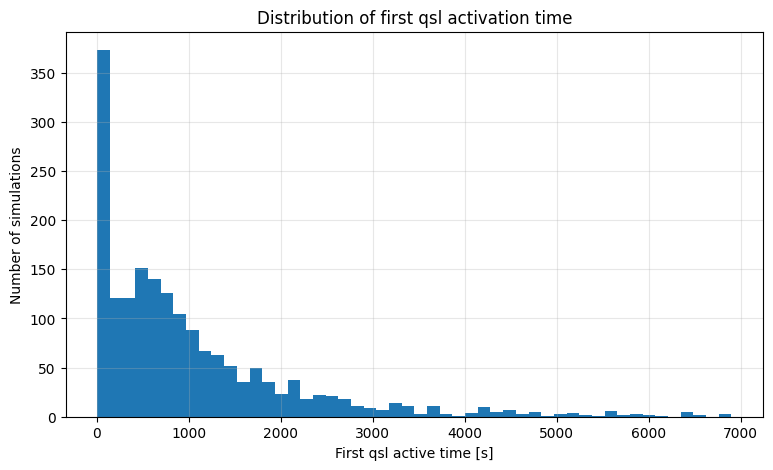

In [38]:
plt.figure(figsize=(9, 5))

plt.hist(
    active_sim["first_active_time"],
    bins=50
)

plt.xlabel("First qsl active time [s]")
plt.ylabel("Number of simulations")
plt.title("Distribution of first qsl activation time")

plt.grid(alpha=0.3)

plt.show()

In [39]:
max_time = (
    train
    .groupby("Simulation No")["time"]
    .max()
    .rename("maximum_time")
)

qsl_sim = qsl_sim.merge(
    max_time,
    on="Simulation No",
)

active_sim = qsl_sim[
    qsl_sim["qsl_active"]
].copy()

active_sim[
    "first_active_time_norm"
] = (
    active_sim["first_active_time"]
    / active_sim["maximum_time"]
)

active_sim[
    "last_active_time_norm"
] = (
    active_sim["last_active_time"]
    / active_sim["maximum_time"]
)

active_sim[
    [
        "first_active_time_norm",
        "last_active_time_norm",
    ]
].describe(
    percentiles=[
        0.01,
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
    ]
)

,first_active_time_norm,last_active_time_norm
count,1805.000000,1805.000000
mean,0.204237,0.572025
std,0.204337,0.339737
min,0.000980,0.001667
1%,0.001607,0.020628
5%,0.004794,0.077118
10%,0.010690,0.119811
25%,0.046555,0.251208
50%,0.142970,0.544981
75%,0.296628,0.986818


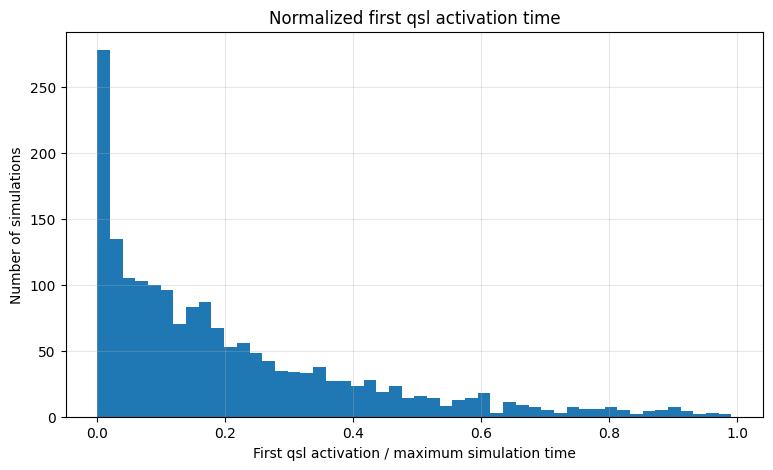

In [40]:
plt.figure(figsize=(9, 5))

plt.hist(
    active_sim["first_active_time_norm"],
    bins=50
)

plt.xlabel(
    "First qsl activation / maximum simulation time"
)

plt.ylabel("Number of simulations")

plt.title(
    "Normalized first qsl activation time"
)

plt.grid(alpha=0.3)

plt.show()

In [41]:
print(
    active_sim[
        "n_active_regions"
    ].value_counts()
    .sort_index()
)

n_active_regions
1      608
2      247
3      161
4      124
5       72
      ... 
116      1
126      1
133      1
144      2
195      1
Name: count, Length: 78, dtype: int64


In [42]:
print(
    "Fraction with one active region:",
    (
        active_sim["n_active_regions"] == 1
    ).mean()
)

print(
    "Fraction with multiple active regions:",
    (
        active_sim["n_active_regions"] > 1
    ).mean()
)

Fraction with one active region: 0.3368421052631579
Fraction with multiple active regions: 0.6631578947368421


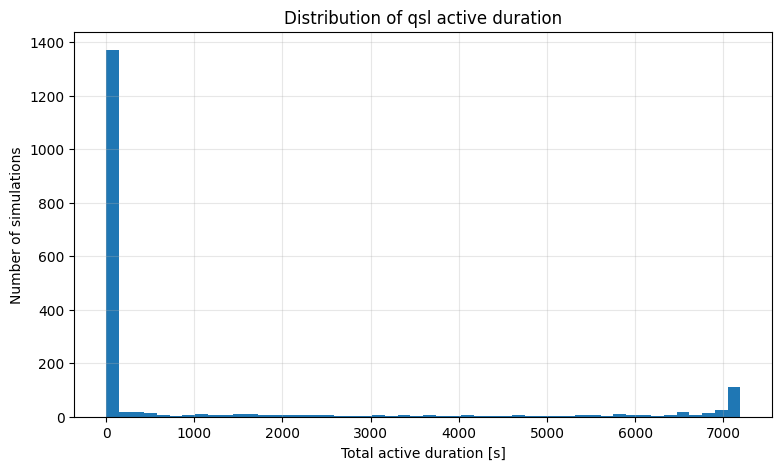

In [43]:
plt.figure(figsize=(9, 5))

plt.hist(
    active_sim["active_duration"],
    bins=50
)

plt.xlabel("Total active duration [s]")
plt.ylabel("Number of simulations")

plt.title(
    "Distribution of qsl active duration"
)

plt.grid(alpha=0.3)

plt.show()

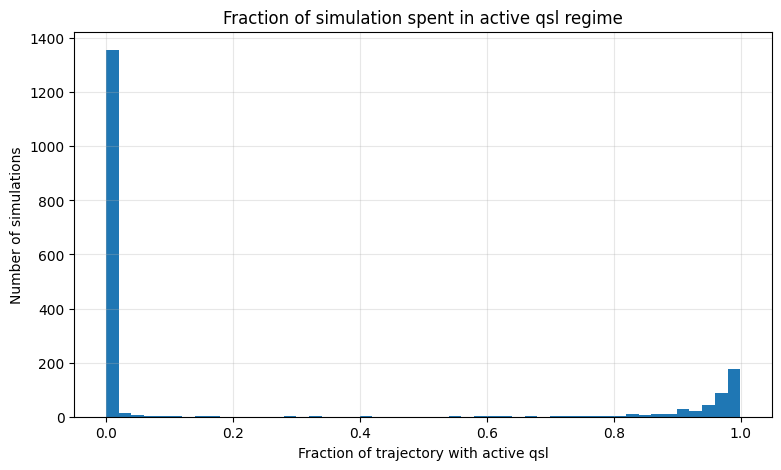

In [44]:
plt.figure(figsize=(9, 5))

plt.hist(
    active_sim["active_fraction"],
    bins=50
)

plt.xlabel(
    "Fraction of trajectory with active qsl"
)

plt.ylabel("Number of simulations")

plt.title(
    "Fraction of simulation spent in active qsl regime"
)

plt.grid(alpha=0.3)

plt.show()

In [45]:
rng = np.random.default_rng(42)

example_ids = rng.choice(
    active_sim["Simulation No"].to_numpy(),
    size=6,
    replace=False,
)

example_ids

array([3264, 3821, 2156, 4239, 2181,  420])

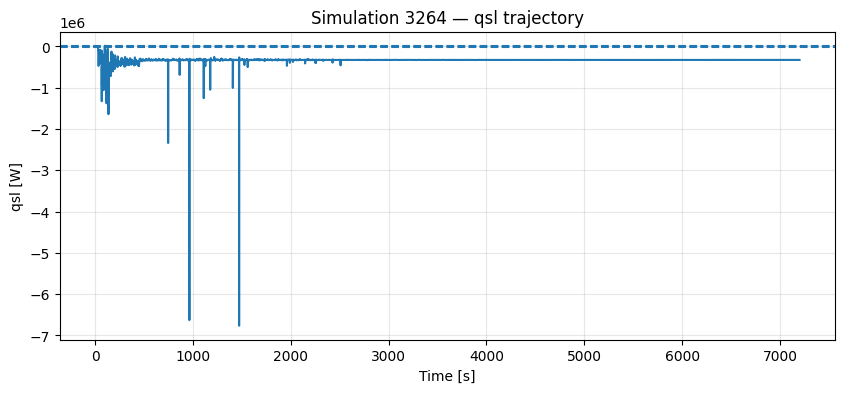

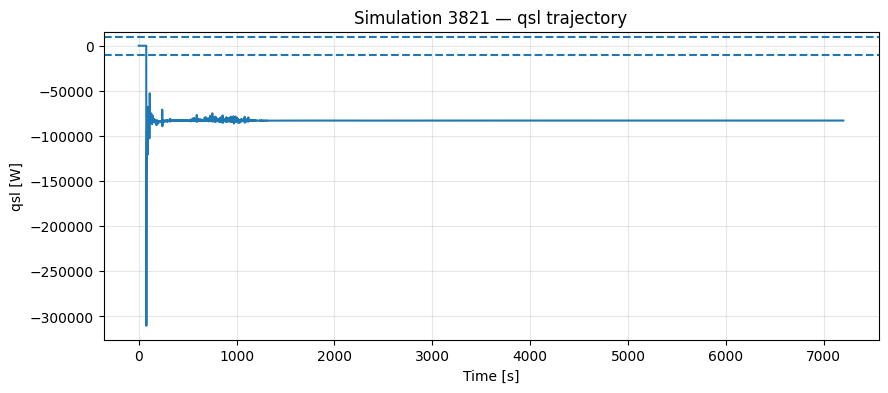

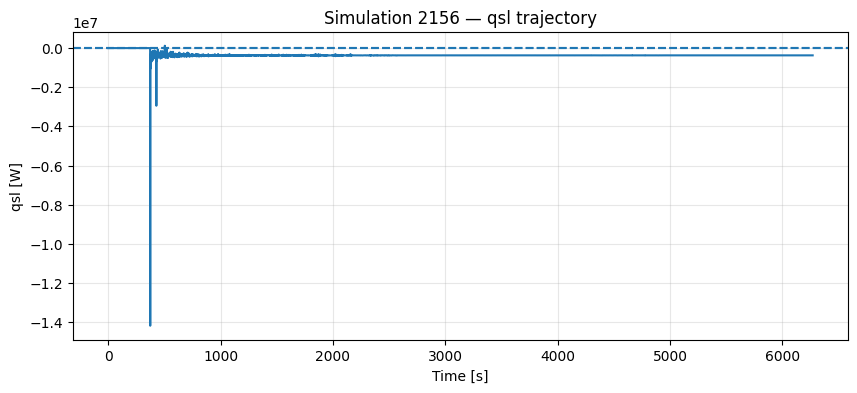

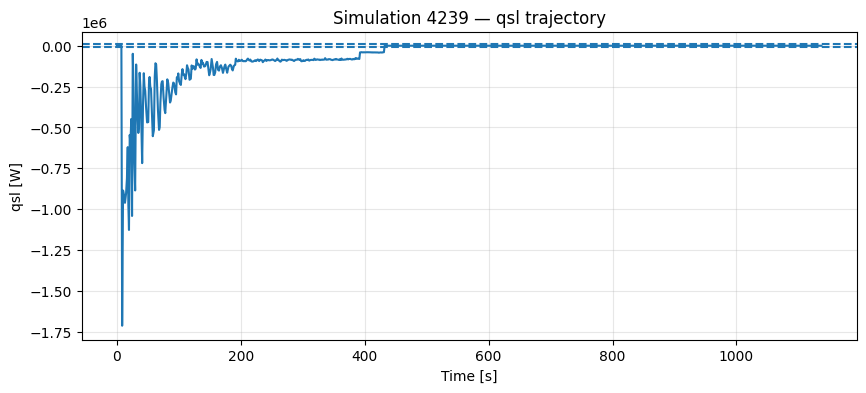

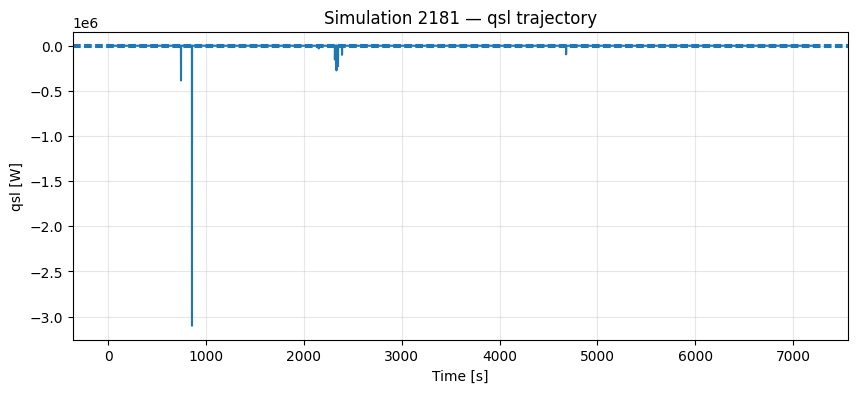

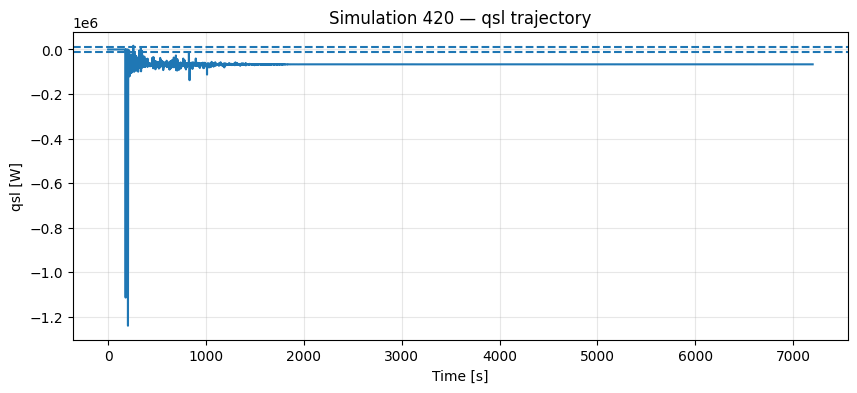

In [46]:
for simid in example_ids:

    g = train[
        train["Simulation No"] == simid
    ].sort_values("time")

    plt.figure(figsize=(10, 4))

    plt.plot(
        g["time"],
        g["qsl"],
    )

    plt.axhline(
        QSL_THRESHOLD,
        linestyle="--",
    )

    plt.axhline(
        -QSL_THRESHOLD,
        linestyle="--",
    )

    plt.xlabel("Time [s]")
    plt.ylabel("qsl [W]")

    plt.title(
        f"Simulation {simid} — qsl trajectory"
    )

    plt.grid(alpha=0.3)

    plt.show()

In [47]:
PARAMETERS = [
    "Psys",
    "Ffuel",
    "Porosity",
    "Dparticle",
    "Alpha",
    "Rflat",
    "Tbed",
    "Decay",
    "Fstruct",
    "Rcake",
    "Topcake",
    "Botcake",
    "Porcake",
    "Partdiacake",
    "Hdebris",
]

In [50]:
# Get one row per simulation containing the initial parameters
initial_state = (
    train
    .sort_values("time")
    .groupby("Simulation No")
    .first()
    .reset_index()
)

initial_state = initial_state[
    ["Simulation No"] + PARAMETERS
]


# ------------------------------------------------------------
# Add qsl temporal information
# ------------------------------------------------------------

# qsl_sim already contains:
#   qsl_active
#   first_active_time
#   maximum_time

qsl_info = qsl_sim[
    [
        "Simulation No",
        "qsl_active",
        "first_active_time",
        "maximum_time",
    ]
].copy()

# Calculate normalized activation time here
qsl_info["first_active_time_norm"] = (
    qsl_info["first_active_time"]
    / qsl_info["maximum_time"]
)


# ------------------------------------------------------------
# Merge
# ------------------------------------------------------------

initial_state = initial_state.merge(
    qsl_info[
        [
            "Simulation No",
            "qsl_active",
            "first_active_time_norm",
        ]
    ],
    on="Simulation No",
    how="left",
)


# ------------------------------------------------------------
# Parameter comparison
# ------------------------------------------------------------

parameter_comparison = (
    initial_state
    .groupby("qsl_active")[PARAMETERS]
    .median()
    .T
)

parameter_comparison.columns = [
    "inactive",
    "active",
]


# ------------------------------------------------------------
# Relative difference
# ------------------------------------------------------------

parameter_comparison[
    "relative_difference_%"
] = (
    (
        parameter_comparison["active"]
        -
        parameter_comparison["inactive"]
    )
    /
    parameter_comparison["inactive"].abs()
    * 100
)


parameter_comparison = (
    parameter_comparison
    .sort_values(
        "relative_difference_%",
        key=np.abs,
        ascending=False,
    )
)

parameter_comparison

,inactive,active,relative_difference_%
Fstruct,0.948425,1.322925,39.486517
Tbed,912.330000,1205.610000,32.146263
Dparticle,0.003503,0.002455,-29.918922
Rcake,0.428544,0.553523,29.163549
Decay,0.007247,0.005449,-24.805089
Partdiacake,0.001622,0.001222,-24.669922
Psys,330701.000000,273839.000000,-17.194384
Porosity,0.351825,0.394925,12.250409
Hdebris,1.941383,2.166657,11.603813
Topcake,0.838303,0.933586,11.366238


In [52]:
# ------------------------------------------------------------
# QSL peak / timing / late-state analysis
# ------------------------------------------------------------

def qsl_summary(g):

    g = g.sort_values("time")

    qsl = g["qsl"].to_numpy()
    time = g["time"].to_numpy()

    max_abs_idx = np.argmax(np.abs(qsl))

    tmax = time[-1]

    late_mask = time >= 0.9 * tmax

    return pd.Series({
        "qsl_peak_abs": np.abs(qsl[max_abs_idx]),
        "qsl_peak_signed": qsl[max_abs_idx],
        "qsl_peak_time": time[max_abs_idx],
        "qsl_peak_time_norm": time[max_abs_idx] / tmax,

        "qsl_late_mean": np.mean(qsl[late_mask]),
        "qsl_late_median": np.median(qsl[late_mask]),
        "qsl_late_std": np.std(qsl[late_mask]),

        "qsl_initial": qsl[0],
        "qsl_final": qsl[-1],

        "qsl_mean": np.mean(qsl),
        "qsl_std": np.std(qsl),
    })


qsl_summary_df = (
    train
    .groupby("Simulation No")
    .apply(qsl_summary)
    .reset_index()
)

qsl_summary_df.head()

/tmp/ipykernel_2146915/320162148.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(qsl_summary)


,Simulation No,qsl_peak_abs,qsl_peak_signed,qsl_peak_time,qsl_peak_time_norm,qsl_late_mean,qsl_late_median,qsl_late_std,qsl_initial,qsl_final,qsl_mean,qsl_std
0,0,0.0,0.0,0.00100,4.627480e-07,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
1,3,3702980.8,-3702980.8,553.49426,2.211918e-01,0.0,0.0,0.0,0.0,0.0,-1788.879614,81369.446183
2,4,0.0,0.0,0.00100,1.088598e-06,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
3,6,0.0,0.0,0.00100,2.144108e-06,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
4,7,0.0,0.0,0.00100,4.530874e-07,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000


In [53]:
qsl_summary_df.describe(
    percentiles=[
        0.01,
        0.05,
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
    ]
)

,Simulation No,qsl_peak_abs,qsl_peak_signed,qsl_peak_time,qsl_peak_time_norm,qsl_late_mean,qsl_late_median,qsl_late_std,qsl_initial,qsl_final,qsl_mean,qsl_std
count,3956.000000,3.956000e+03,3.956000e+03,3956.000000,3.956000e+03,3.956000e+03,3.956000e+03,3956.000000,3956.0,3.956000e+03,3.956000e+03,3956.000000
mean,2491.348837,1.077915e+06,-1.077550e+06,681.407675,1.308472e-01,-2.569461e+04,-2.564052e+04,827.550713,0.0,-2.562033e+04,-2.645745e+04,25166.975210
std,1444.252854,2.980359e+06,2.980491e+06,1203.898038,2.098565e-01,1.160192e+05,1.159788e+05,8427.198102,0.0,1.153808e+05,1.173529e+05,71724.892927
min,0.000000,0.000000e+00,-5.441194e+07,0.001000,1.388889e-07,-1.811937e+06,-1.813459e+06,0.000000,0.0,-1.815576e+06,-1.799568e+06,0.000000
1%,56.100000,0.000000e+00,-1.421036e+07,0.001000,1.388889e-07,-5.947091e+05,-5.948618e+05,0.000000,0.0,-5.908626e+05,-5.847338e+05,0.000000
5%,243.750000,0.000000e+00,-5.618798e+06,0.001000,1.388901e-07,-1.599202e+05,-1.599521e+05,0.000000,0.0,-1.622928e+05,-1.618641e+05,0.000000
10%,477.500000,0.000000e+00,-3.016290e+06,0.001000,1.388978e-07,-3.349940e+04,-3.333053e+04,0.000000,0.0,-3.350341e+04,-3.693255e+04,0.000000
25%,1243.750000,0.000000e+00,-7.559697e+05,0.001000,1.911384e-07,0.000000e+00,0.000000e+00,0.000000,0.0,0.000000e+00,-4.135465e+02,0.000000
50%,2487.500000,0.000000e+00,0.000000e+00,0.001000,2.691064e-06,0.000000e+00,0.000000e+00,0.000000,0.0,0.000000e+00,0.000000e+00,0.000000
75%,3734.250000,7.559697e+05,0.000000e+00,913.699343,1.974247e-01,0.000000e+00,0.000000e+00,0.000000,0.0,0.000000e+00,0.000000e+00,15212.467830


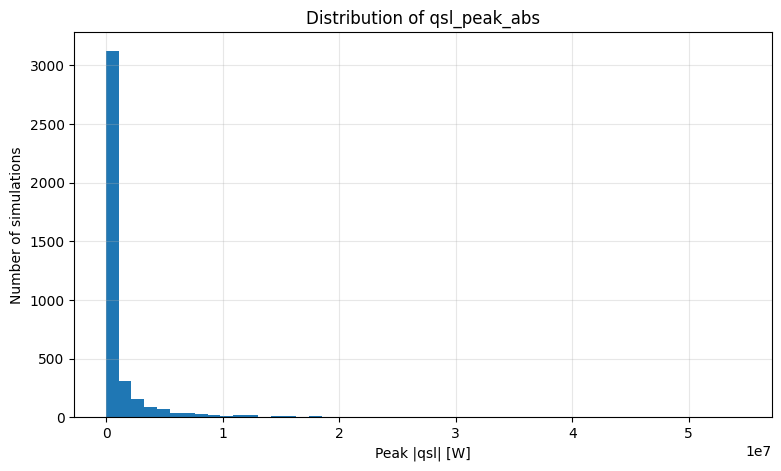

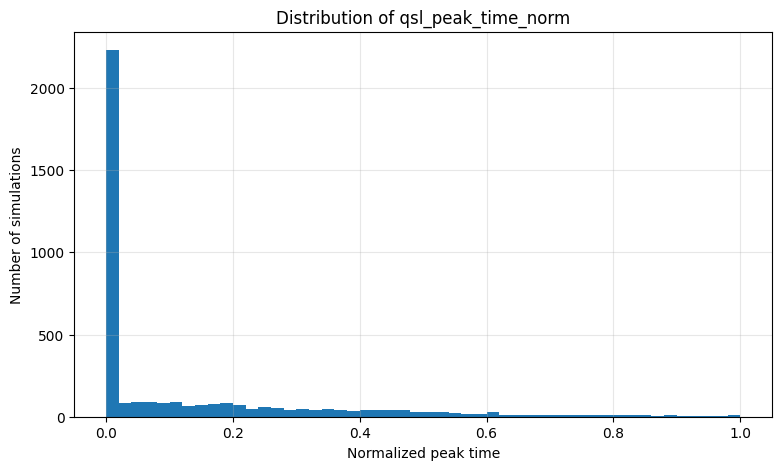

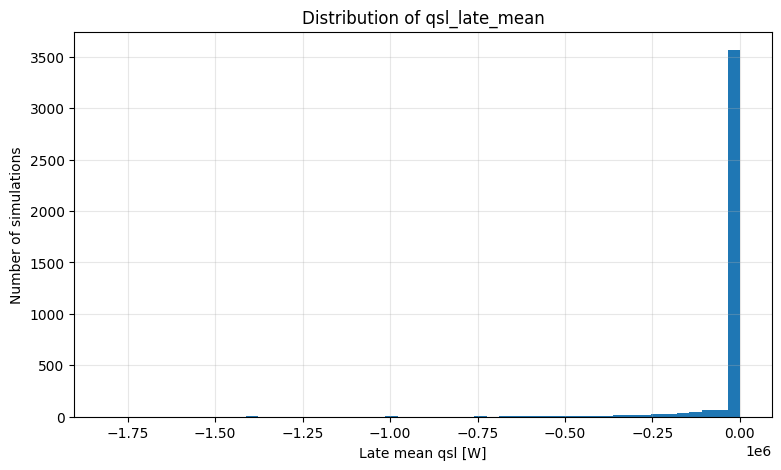

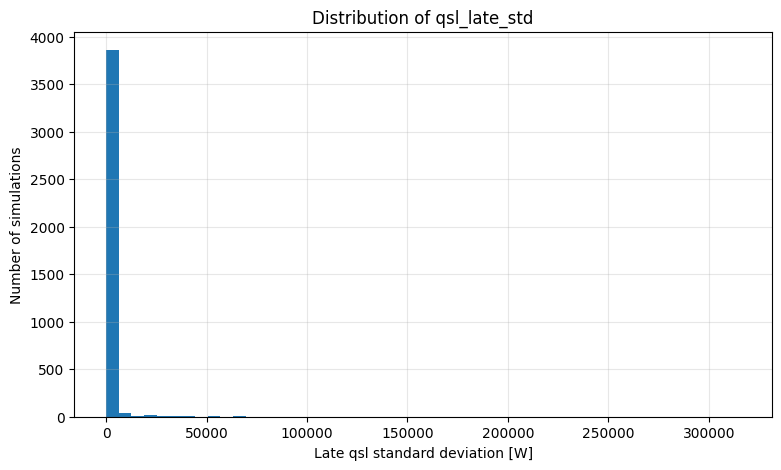

In [54]:
figures = [
    ("qsl_peak_abs", "Peak |qsl| [W]"),
    ("qsl_peak_time_norm", "Normalized peak time"),
    ("qsl_late_mean", "Late mean qsl [W]"),
    ("qsl_late_std", "Late qsl standard deviation [W]"),
]

for column, xlabel in figures:

    plt.figure(figsize=(9, 5))

    plt.hist(
        qsl_summary_df[column].replace(
            [np.inf, -np.inf],
            np.nan
        ).dropna(),
        bins=50
    )

    plt.xlabel(xlabel)
    plt.ylabel("Number of simulations")
    plt.title(f"Distribution of {column}")

    plt.grid(alpha=0.3)

    plt.show()

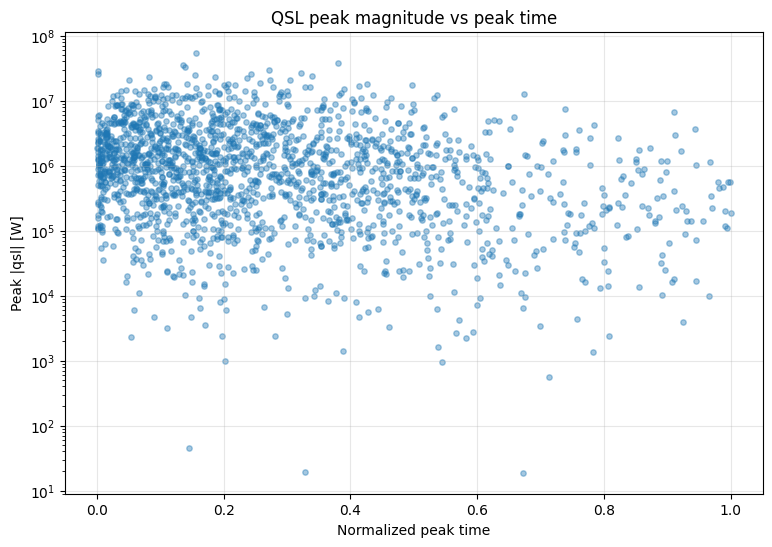

In [55]:
plt.figure(figsize=(9, 6))

plt.scatter(
    qsl_summary_df["qsl_peak_time_norm"],
    qsl_summary_df["qsl_peak_abs"],
    alpha=0.4,
    s=15,
)

plt.yscale("log")

plt.xlabel("Normalized peak time")
plt.ylabel("Peak |qsl| [W]")
plt.title("QSL peak magnitude vs peak time")

plt.grid(alpha=0.3)

plt.show()